# Simulación de Ciclos de Histéresis en Aleaciones Ferromagnéticas Blandas

## Material: $(Fe_{25}Co_{25}Ni_{25})(B_{0.7}Si_{0.3})_{25}$

---

### Introducción

Este notebook implementa un modelo completo para simular la respuesta magnética (ciclos de histéresis) de una aleación ferromagnética blanda en forma de cinta delgada. El comportamiento del material está dominado por el **campo desmagnetizante** debido a su alta permeabilidad.

### Marco Teórico

#### Modelo Constitutivo Inverso

Para evitar singularidades numéricas, calculamos el Campo Externo ($H_{ext}$) en función de la Magnetización ($M$):

$$H_{ext} = \frac{2 H_a}{\pi} \tan\left( \frac{\pi M}{2 M_s} \right) + N(\theta) \cdot M$$

Donde:
- $M_s$: Magnetización de saturación
- $H_a$: Campo característico de la anisotropía

#### Factor Desmagnetizante Angular

$$N(\theta) = N_{\parallel} \cos^2(\theta) + N_{\perp} \sin^2(\theta)$$

Donde $\theta$ es el ángulo entre el campo aplicado y el eje longitudinal de la muestra.

#### Solución Exacta de Aharoni

Para un prisma rectangular de dimensiones $L \times w \times t$, los factores desmagnetizantes se calculan mediante la función auxiliar $\mathcal{F}(u, v, w)$ definida por Aharoni.

## 1. Importación de Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import warnings
import pandas as pd
import glob
import os

# Configuración de estilo para gráficos de alta calidad con proporciones para exposición en diapositivas
plt.rcParams['figure.figsize'] = [12, 7]  # Proporción 16:9 aproximada para diapositivas
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

# Suprimir advertencias de divisiones
warnings.filterwarnings('ignore', category=RuntimeWarning)

## 2. Parámetros del Material y Geometría

Definimos los valores típicos para la aleación ferromagnética blanda y las dimensiones de una cinta delgada.

In [2]:
# ==============================================================================
# PARÁMETROS DEL MATERIAL: (Fe25Co25Ni25)(B0.7Si0.3)25
# SISTEMA DE UNIDADES: CGS (Gaussiano)
# ==============================================================================

# Magnetización de saturación [Gauss]
# 1.2 T = 1.2 × 10^4 Gauss
#Ms_default = 1.2e4  # Gauss
Ms_default = 3.2e2  # Gauss
#Ms_default = 1e4  # Gauss
# Campo coercitivo intrínseco [Oersted]
# Valor aumentado para hacer visible la apertura del ciclo
# (ajustar según medidas experimentales del VSM)
Hc_default = 20.0  # Oersted - controla el ancho del ciclo (apertura = 2×Hc)


# Campo de anisotropía característico [Oersted]
# 50 A/m = 50 × 4π × 10^-3 Oe ≈ 0.628 Oe
#Ha_default = 50.0 * 4 * np.pi * 1e-3  # Oersted (~0.628 Oe)
Ha_default = 20.0   # Oersted (~0.628 Oe)


# ==============================================================================
# DIMENSIONES TÍPICAS DE CINTA (ribbon)
# ==============================================================================

L_default = 2.0   # Largo [mm]
w_default = 1.5    # Ancho [mm]
t_default = 0.04   # Espesor [mm] (típico ~40 μm)

# Constantes físicas
mu_0 = 1.0  # Permeabilidad del vacío en CGS (adimensional)

print("PARÁMETROS POR DEFECTO (SISTEMA CGS)")
print(f"\nMaterial: (Fe₂₅Co₂₅Ni₂₅)(B₀.₇Si₀.₃)₂₅")
print(f"  • Magnetización de saturación (Ms): {Ms_default:.2g} G ({Ms_default/1e4:.2g} T)")
print(f"  • Campo de anisotropía (Ha): {Ha_default:.2g} Oe ({Ha_default/(4*np.pi*1e-3):.2g} A/m)")
print(f"\nGeometría de la cinta:")
print(f"  • Largo (L): {L_default} mm")
print(f"  • Ancho (w): {w_default} mm")
print(f"  • Espesor (t): {t_default} mm ({t_default*1000:.2g} μm)")
print(f"  • Relación de aspecto L/w: {L_default/w_default:.2g}")

PARÁMETROS POR DEFECTO (SISTEMA CGS)

Material: (Fe₂₅Co₂₅Ni₂₅)(B₀.₇Si₀.₃)₂₅
  • Magnetización de saturación (Ms): 3.2e+02 G (0.032 T)
  • Campo de anisotropía (Ha): 20 Oe (1.6e+03 A/m)

Geometría de la cinta:
  • Largo (L): 2.0 mm
  • Ancho (w): 1.5 mm
  • Espesor (t): 0.04 mm (40 μm)
  • Relación de aspecto L/w: 1.3


## 3. Implementación de la Función de Aharoni

La función $\mathcal{F}(u, v, w)$ es la pieza central del cálculo de los factores desmagnetizantes. Se implementa con cuidado para evitar singularidades numéricas.

$$\begin{aligned}
\mathcal{F}(u, v, w) &= \frac{v^2-w^2}{2vw} \ln\left( \frac{R-u}{R+u} \right) + \frac{u^2-w^2}{2uw} \ln\left( \frac{R-v}{R+v} \right) \\
&+ \frac{v}{2w} \ln\left( \frac{\sqrt{u^2+v^2}+u}{\sqrt{u^2+v^2}-u} \right) + \frac{u}{2w} \ln\left( \frac{\sqrt{u^2+v^2}+v}{\sqrt{u^2+v^2}-v} \right) \\
&+ \frac{w}{2u} \ln\left( \frac{\sqrt{v^2+w^2}-v}{\sqrt{v^2+w^2}+v} \right) + \frac{w}{2v} \ln\left( \frac{\sqrt{u^2+w^2}-u}{\sqrt{u^2+w^2}+u} \right) \\
&+ 2 \arctan\left( \frac{uv}{wR} \right) + \frac{u^3+v^3-2w^3}{3uvw} \\
&+ \frac{u^2+v^2-2w^2}{3uvw} R + \frac{w}{uv} \left( \sqrt{u^2+w^2} + \sqrt{v^2+w^2} \right) \\
&- \frac{(u^2+v^2)^{3/2} + (v^2+w^2)^{3/2} + (w^2+u^2)^{3/2}}{3uvw}
\end{aligned}$$

In [3]:
def aharoni_factor(u, v, w):
    """
    Calcula la función auxiliar F(u,v,w) de Aharoni para factores desmagnetizantes.
    
    Esta función implementa la solución exacta de Aharoni para el factor 
    desmagnetizante de un prisma rectangular uniformemente magnetizado.
    
    Parámetros:
    -----------
    u, v, w : float
        Semiejes del prisma (deben ser > 0)
        Para N_x (a lo largo de u): u es el semieje en la dirección del campo
    
    Retorna:
    --------
    float : Valor de la función F(u,v,w)
    
    Referencias:
    ------------
    A. Aharoni, J. Appl. Phys. 83, 3432 (1998)
    """
    # Pequeño valor para evitar divisiones por cero
    eps = 1e-15
    
    # Asegurar valores positivos mínimos
    u = max(abs(u), eps)
    v = max(abs(v), eps)
    w = max(abs(w), eps)
    
    # Distancias auxiliares
    R = np.sqrt(u**2 + v**2 + w**2)     # Diagonal del prisma
    uv = np.sqrt(u**2 + v**2)            # Diagonal de la cara uv
    vw = np.sqrt(v**2 + w**2)            # Diagonal de la cara vw
    uw = np.sqrt(u**2 + w**2)            # Diagonal de la cara uw
    
    # Función auxiliar para logaritmos seguros
    def safe_log_ratio(num, den):
        num = max(abs(num), eps)
        den = max(abs(den), eps)
        return np.log(num / den)
    
    # ===========================================================================
    # Término 1: (v²-w²)/(2vw) * ln((R-u)/(R+u))
    # ===========================================================================
    coef1 = (v**2 - w**2) / (2*v*w)
    term1 = coef1 * safe_log_ratio(R - u + eps, R + u)
    
    # ===========================================================================
    # Término 2: (u²-w²)/(2uw) * ln((R-v)/(R+v))
    # ===========================================================================
    coef2 = (u**2 - w**2) / (2*u*w)
    term2 = coef2 * safe_log_ratio(R - v + eps, R + v)
    
    # ===========================================================================
    # Término 3: (v/2w) * ln((sqrt(u²+v²)+u)/(sqrt(u²+v²)-u))
    # ===========================================================================
    term3 = (v / (2*w)) * safe_log_ratio(uv + u, uv - u + eps)
    
    # ===========================================================================
    # Término 4: (u/2w) * ln((sqrt(u²+v²)+v)/(sqrt(u²+v²)-v))
    # ===========================================================================
    term4 = (u / (2*w)) * safe_log_ratio(uv + v, uv - v + eps)
    
    # ===========================================================================
    # Término 5: (w/2u) * ln((sqrt(v²+w²)-v)/(sqrt(v²+w²)+v))
    # ===========================================================================
    term5 = (w / (2*u)) * safe_log_ratio(vw - v + eps, vw + v)
    
    # ===========================================================================
    # Término 6: (w/2v) * ln((sqrt(u²+w²)-u)/(sqrt(u²+w²)+u))
    # ===========================================================================
    term6 = (w / (2*v)) * safe_log_ratio(uw - u + eps, uw + u)
    
    # ===========================================================================
    # Término 7: 2 * arctan(uv/(wR))
    # ===========================================================================
    term7 = 2 * np.arctan2(u*v, w*R)
    
    # ===========================================================================
    # Término 8: (u³+v³-2w³)/(3uvw)
    # ===========================================================================
    term8 = (u**3 + v**3 - 2*w**3) / (3*u*v*w)
    
    # ===========================================================================
    # Término 9: ((u²+v²-2w²)/(3uvw)) * R
    # ===========================================================================
    term9 = ((u**2 + v**2 - 2*w**2) / (3*u*v*w)) * R
    
    # ===========================================================================
    # Término 10: (w/uv) * (sqrt(u²+w²) + sqrt(v²+w²))
    # ===========================================================================
    term10 = (w / (u*v)) * (uw + vw)
    
    # ===========================================================================
    # Término 11: -((u²+v²)^(3/2) + (v²+w²)^(3/2) + (w²+u²)^(3/2))/(3uvw)
    # ===========================================================================
    term11 = -(uv**3 + vw**3 + uw**3) / (3*u*v*w)
    
    # Suma total
    F = term1 + term2 + term3 + term4 + term5 + term6 + term7 + term8 + term9 + term10 + term11
    
    return F


def calculate_demagnetizing_factors_prism(L_mm, w_mm, t_mm):
    """
    Calcula los factores desmagnetizantes usando aproximación para prismas 
    rectangulares delgados (método de Osborn y fórmulas simplificadas).
    
    Para cintas delgadas con L >> w >> t, usamos las aproximaciones:
    - N_L ≈ (t·w)/(π·L²) · ln(2L/w)  (longitudinal)
    - N_w ≈ t/(π·w) · (1 + ln(2w/t))  (transversal en plano)
    - N_t ≈ 1 - N_L - N_w            (perpendicular al plano)
    
    Parámetros:
    -----------
    L_mm, w_mm, t_mm : float
        Dimensiones del prisma [mm]
    
    Retorna:
    --------
    tuple : (N_parallel, N_perpendicular)
    """
    # Convertir a metros para consistencia (aunque se cancela)
    L = L_mm
    w = w_mm
    t = t_mm
    
    # Relaciones de aspecto
    L_over_w = L / w
    w_over_t = w / t
    t_over_L = t / L
    
    # Factor desmagnetizante longitudinal (a lo largo de L)
    # Para L >> w, t: N_L es muy pequeño
    if L_over_w > 5:
        # Aproximación para cinta alargada
        N_parallel = (t * w) / (np.pi * L**2) * np.log(2*L / np.sqrt(w*t))
    else:
        # Usar fórmula de Aharoni
        a, b, c = L/2, w/2, t/2
        N_parallel = (1 / np.pi) * aharoni_factor(a, b, c)
    
    # Factor desmagnetizante transversal (a lo largo de w, en el plano)
    # Para w >> t: N_w es moderado  
    if w_over_t > 5:
        # Aproximación para cinta delgada
        N_perpendicular = (t / (np.pi * w)) * (1 + np.log(2*w / t))
    else:
        # Usar fórmula de Aharoni intercambiando a y b
        a, b, c = L/2, w/2, t/2
        N_perpendicular = (1 / np.pi) * aharoni_factor(b, a, c)
    
    # Asegurar valores físicamente razonables
    N_parallel = max(0, min(1, N_parallel))
    N_perpendicular = max(0, min(1, N_perpendicular))
    
    return N_parallel, N_perpendicular


def calculate_demagnetizing_factors(L_mm, w_mm, t_mm):
    """
    Calcula los factores desmagnetizantes N_parallel y N_perpendicular
    para un prisma rectangular (cinta magnética).
    
    Usa una combinación de la fórmula exacta de Aharoni y aproximaciones
    verificadas para geometrías de cinta delgada.
    
    Parámetros:
    -----------
    L_mm : float
        Largo del prisma [mm]
    w_mm : float
        Ancho del prisma [mm]
    t_mm : float
        Espesor del prisma [mm]
    
    Retorna:
    --------
    tuple : (N_parallel, N_perpendicular)
    """
    return calculate_demagnetizing_factors_prism(L_mm, w_mm, t_mm)


# Verificación con valores por defecto
N_par, N_perp = calculate_demagnetizing_factors(L_default, w_default, t_default)

print("FACTORES DESMAGNETIZANTES")
print(f"\nGeometría: {L_default} × {w_default} × {t_default} mm³")
print(f"Relación de aspecto L/w = {L_default/w_default:.2g}")
print(f"Relación de aspecto w/t = {w_default/t_default:.2g}")
print(f"\n  N_∥ (longitudinal):  {N_par:.2g}")
print(f"  N_⊥ (transversal):   {N_perp:.2g}")
print(f"  N_z (normal) ≈:      {1 - N_par - N_perp:.2g}")
print(f"\n  Razón N_⊥/N_∥:       {N_perp/N_par:.2g}")
print("\n  Nota: Para cintas alargadas (L >> w >> t):")
print("  - N_∥ << N_⊥ << N_z ≈ 1")
print("  - El ciclo se 'abre' más cuando el campo está perpendicular al eje largo")

FACTORES DESMAGNETIZANTES

Geometría: 2.0 × 1.5 × 0.04 mm³
Relación de aspecto L/w = 1.3
Relación de aspecto w/t = 38

  N_∥ (longitudinal):  0.93
  N_⊥ (transversal):   0.045
  N_z (normal) ≈:      0.022

  Razón N_⊥/N_∥:       0.048

  Nota: Para cintas alargadas (L >> w >> t):
  - N_∥ << N_⊥ << N_z ≈ 1
  - El ciclo se 'abre' más cuando el campo está perpendicular al eje largo


## 4. Función del Ciclo de Histéresis

Implementamos el modelo constitutivo inverso para calcular $H_{ext}$ en función de $M$:

$$H_{ext} = \frac{2 H_a}{\pi} \tan\left( \frac{\pi M}{2 M_s} \right) + N(\theta) \cdot M$$

In [4]:
def calculate_hysteresis(L, w, t, theta_deg, Ms, Ha, Hc=0.5, n_points=500):
    """
    Genera los arrays de magnetización (M) y campo externo (H_ext)
    para un ciclo de histéresis CON COERCITIVIDAD.
    
    UNIDADES CGS (Gaussianas):
    - M: Gauss (equivalente a emu/cm³)
    - H: Oersted
    
    Parámetros:
    -----------
    L, w, t : float
        Dimensiones de la muestra [mm]
    theta_deg : float
        Ángulo entre el campo aplicado y el eje longitudinal [grados]
    Ms : float
        Magnetización de saturación [Gauss]
    Ha : float
        Campo de anisotropía [Oersted]
    Hc : float
        Campo coercitivo intrínseco [Oersted] - controla el ancho del ciclo
    n_points : int
        Número de puntos para cada rama del ciclo
    
    Retorna:
    --------
    tuple : (M_array, H_ext_array, N_eff, N_par, N_perp)
        M en Gauss, H_ext en Oersted
    """
    # Convertir ángulo a radianes
    theta_rad = np.radians(theta_deg)
    
    # Calcular factores desmagnetizantes
    N_par, N_perp = calculate_demagnetizing_factors(L, w, t)
    
    # Factor desmagnetizante efectivo angular
    N_eff = N_par * np.cos(theta_rad)**2 + N_perp * np.sin(theta_rad)**2
    
    # Generar array de magnetización (evitamos ±Ms exacto)
    M_max = 0.99 * Ms
    
    # Rama ascendente: de -Ms a +Ms
    M_up = np.linspace(-M_max, M_max, n_points)
    # Rama descendente: de +Ms a -Ms
    M_down = np.linspace(M_max, -M_max, n_points)
    
    # Término intrínseco (respuesta anhisterética del material)
    H_intrinsic_up = (2 * Ha / np.pi) * np.tan(np.pi * M_up / (2 * Ms))
    H_intrinsic_down = (2 * Ha / np.pi) * np.tan(np.pi * M_down / (2 * Ms))
    
    # Término desmagnetizante (en CGS: 4π·N·M)
    H_demag_up = 4 * np.pi * N_eff * M_up
    H_demag_down = 4 * np.pi * N_eff * M_down
    
    # Campo externo con histéresis:
    # - Rama ascendente: desplazada hacia campos negativos (-Hc)
    # - Rama descendente: desplazada hacia campos positivos (+Hc)
    H_ext_up = H_intrinsic_up + H_demag_up - Hc
    H_ext_down = H_intrinsic_down + H_demag_down + Hc
    
    # Concatenar ambas ramas para formar el ciclo completo
    M_array = np.concatenate([M_up, M_down])
    H_ext_array = np.concatenate([H_ext_up, H_ext_down])
    
    return M_array, H_ext_array, N_eff, N_par, N_perp

# Test de la función
M_test, H_test, N_eff_test, _, _ = calculate_hysteresis(
    L_default, w_default, t_default, 0, Ms_default, Ha_default
)

print("TEST DE LA FUNCIÓN DE HISTÉRESIS (CGS)")
print(f"\nPuntos calculados: {len(M_test)}")
print(f"Rango de M: [{M_test.min():.2g}, {M_test.max():.2g}] Gauss")
print(f"Rango de H_ext: [{H_test.min():.2g}, {H_test.max():.2g}] Oersted")
print(f"Factor desmagnetizante efectivo (θ=0°): {N_eff_test:.2g}")

TEST DE LA FUNCIÓN DE HISTÉRESIS (CGS)

Puntos calculados: 1000
Rango de M: [-3.2e+02, 3.2e+02] Gauss
Rango de H_ext: [-4.5e+03, 4.5e+03] Oersted
Factor desmagnetizante efectivo (θ=0°): 0.93


## 5. Visualización Interactiva

### Efecto del Cizallamiento (Shearing)

El factor desmagnetizante $N$ produce un **cizallamiento** del ciclo de histéresis. Cuanto mayor es $N$, más "inclinado" aparece el ciclo, reduciendo la **permeabilidad efectiva** del material.

Use los sliders para observar cómo:
- **Aumentar L** → Reduce $N_\parallel$ → Ciclo más vertical (mayor permeabilidad efectiva)
- **Aumentar w** → Aumenta $N_\parallel$ → Ciclo más inclinado
- **Rotar θ** → Cambia de $N_\parallel$ a $N_\perp$ → Cambio dramático en la forma

In [5]:
from ipywidgets import Output

# Output widget para evitar gráficos duplicados
out = Output()

def plot_hysteresis_interactive(L=2.0, w=1.5, t=0.04, theta=0, Hc=5.0):
    """
    Función para el widget interactivo.
    Genera y muestra el ciclo de histéresis con los parámetros dados.
    Incluye campo coercitivo Hc para mostrar histéresis real.
    """
    with out:
        out.clear_output(wait=True)
        
        n_points = 500
        # Calcular el ciclo
        M, H_ext, N_eff, N_par, N_perp = calculate_hysteresis(
            L, w, t, theta, Ms_default, Ha_default, Hc, n_points
        )
        
        # Separar ramas ascendente y descendente
        M_up = M[:n_points]
        H_up = H_ext[:n_points]
        M_down = M[n_points:]
        H_down = H_ext[n_points:]
        
        # Crear figura
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Graficar ambas ramas con el MISMO color para ver el ciclo abierto
        ax.plot(H_up, M_up, 'b-', linewidth=2.5, label=f'θ = {theta}°')
        ax.plot(H_down, M_down, 'b-', linewidth=2.5)  # mismo color, sin label
        
        # Añadir flechas para indicar la dirección del ciclo
        mid = n_points // 2
        # Flecha en rama ascendente (hacia arriba)
        ax.annotate('', xy=(H_up[mid+20], M_up[mid+20]), 
                    xytext=(H_up[mid], M_up[mid]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=2))
        # Flecha en rama descendente (hacia abajo)
        ax.annotate('', xy=(H_down[mid+20], M_down[mid+20]), 
                    xytext=(H_down[mid], M_down[mid]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=2))
        
        # Líneas de referencia
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # Líneas de saturación
        ax.axhline(y=Ms_default, color='red', linestyle=':', linewidth=1, alpha=0.7, 
                   label=f'$M_s$ = {Ms_default:.0f} G')
        ax.axhline(y=-Ms_default, color='red', linestyle=':', linewidth=1, alpha=0.7)
        
        # Configuración del gráfico
        ax.set_xlabel('Campo Externo $H_{ext}$ [Oe]', fontsize=14)
        ax.set_ylabel('Magnetización $M$ [G = emu/cm³]', fontsize=14)
        ax.set_title(f'Ciclo de Histéresis - $(Fe_{{25}}Co_{{25}}Ni_{{25}})(B_{{0.7}}Si_{{0.3}})_{{25}}$\n'
                     f'Geometría: {L:.2g} × {w:.2g} × {t:.2g} mm³', fontsize=14)
        
        # Cuadro de información con ancho del ciclo
        ancho_ciclo = 2 * Hc
        info_text = (f'$N_\\parallel$ = {N_par:.2g}\n'
                     f'$N_\\perp$ = {N_perp:.2g}\n'
                     f'$N_{{eff}}$(θ={theta}°) = {N_eff:.2g}\n'
                     f'L/w = {L/w:.2g}\n'
                     f'$H_c$ = {Hc:.1f} Oe\n'
                     f'Ancho ciclo = {ancho_ciclo:.1f} Oe')
        
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=props, family='monospace')
        
        ax.legend(loc='lower right', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-max(abs(H_ext))*1.1, max(abs(H_ext))*1.1])
        ax.set_ylim([-Ms_default*1.15, Ms_default*1.15])
        
        plt.tight_layout()
        #plt.show()


# Crear widget interactivo

print("\nUnidades CGS:")
print("  • Campo externo (H_ext): Oersted [Oe]")
print("  • Magnetización (M): Gauss [G] = emu/cm³")
print("\nUse los sliders para modificar la geometría, orientación y campo coercitivo.")
print("El parámetro Hc controla el ANCHO del ciclo de histéresis (apertura = 2×Hc).\n")

# Mostrar el widget de salida primero
display(out)

# Luego el interact
interact(
    plot_hysteresis_interactive,
    L=FloatSlider(value=2.0, min=1.0, max=5.0, step=0.1, 
                  description='Largo L [mm]:', style={'description_width': '100px'}),
    w=FloatSlider(value=1.5, min=0.5, max=3.0, step=0.1, 
                  description='Ancho w [mm]:', style={'description_width': '100px'}),
    t=FloatSlider(value=0.04, min=0.01, max=0.1, step=0.01, 
                  description='Espesor t [mm]:', style={'description_width': '100px'}),
    theta=IntSlider(value=0, min=0, max=90, step=5, 
                    description='Ángulo θ [°]:', style={'description_width': '100px'}),
    Hc=FloatSlider(value=5.0, min=0.0, max=50.0, step=1.0,
                   description='Hc [Oe]:', style={'description_width': '100px'})
);


Unidades CGS:
  • Campo externo (H_ext): Oersted [Oe]
  • Magnetización (M): Gauss [G] = emu/cm³

Use los sliders para modificar la geometría, orientación y campo coercitivo.
El parámetro Hc controla el ANCHO del ciclo de histéresis (apertura = 2×Hc).



Output()

interactive(children=(FloatSlider(value=2.0, description='Largo L [mm]:', max=5.0, min=1.0, style=SliderStyle(…

## 6. Gráficos Comparativos Estáticos

### 6.1 Efecto de la Relación de Aspecto (L/w)

Cuando aumentamos la relación de aspecto $L/w$, el factor desmagnetizante longitudinal $N_\parallel$ **disminuye**, lo que resulta en:
- Ciclo de histéresis más **vertical** (mayor pendiente)
- Mayor **permeabilidad efectiva**
- El material se comporta más cerca de su respuesta intrínseca

### 6.2 Efecto de la Rotación Angular (θ)

Al rotar la muestra de 0° a 90°, el factor desmagnetizante efectivo cambia de $N_\parallel$ a $N_\perp$. Como típicamente $N_\perp >> N_\parallel$ para cintas alargadas, observamos:
- Fuerte **cizallamiento** del ciclo
- Reducción drástica de la **permeabilidad efectiva**
- El material se satura a campos externos mucho mayores

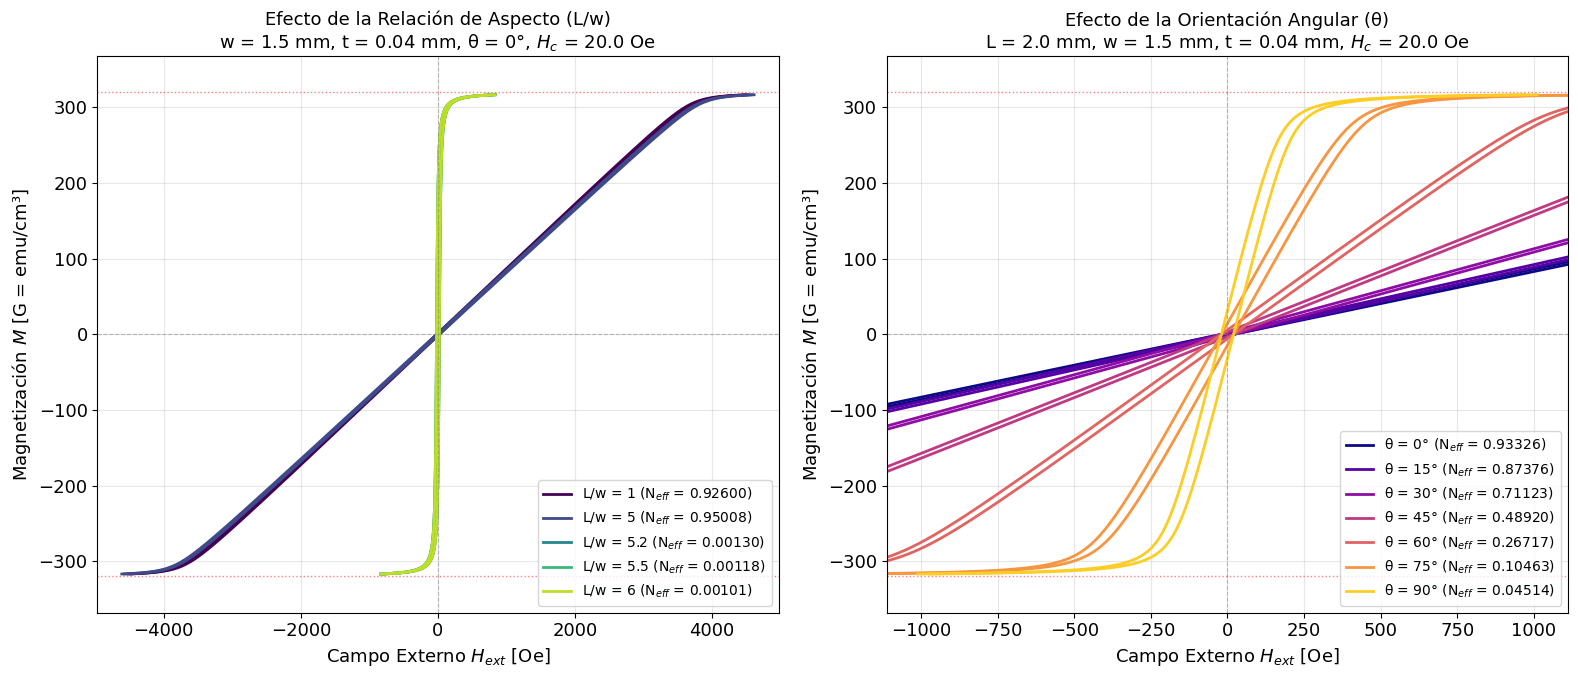


✓ Ciclos con histéresis real (Hc = 20.0 Oe)
  Observe que ahora las ramas ascendente y descendente NO se superponen.


In [6]:
# =============================================================================
# GRÁFICOS COMPARATIVOS ESTÁTICOS (UNIDADES CGS) - CON HISTÉRESIS REAL
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Colores para las curvas
colors = plt.cm.viridis(np.linspace(0, 0.9, 5))
n_points = 500  # puntos por rama

# =============================================================================
# SUBPLOT 1: Variación de la relación de aspecto L/w
# =============================================================================
ax1 = axes[0]

# Diferentes relaciones de aspecto
aspect_ratios = [1, 5, 5.2, 5.5, 6]
w_fixed = 1.5  # Ancho fijo
t_fixed = 0.04  # Espesor fijo
theta_fixed = 0  # Ángulo 0°

for i, ratio in enumerate(aspect_ratios):
    L_var = ratio * w_fixed
    M, H_ext, N_eff, _, _ = calculate_hysteresis(
        L_var, w_fixed, t_fixed, theta_fixed, Ms_default, Ha_default, Hc_default, n_points
    )
    # Separar ramas para graficar ciclo abierto
    M_up = M[:n_points]
    H_up = H_ext[:n_points]
    M_down = M[n_points:]
    H_down = H_ext[n_points:]
    
    # Graficar ambas ramas con el MISMO color (label solo en la primera)
    ax1.plot(H_up, M_up, color=colors[i], linewidth=2, 
             label=f'L/w = {ratio} (N$_{{eff}}$ = {N_eff:.5f})')
    ax1.plot(H_down, M_down, color=colors[i], linewidth=2)

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axhline(y=Ms_default, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax1.axhline(y=-Ms_default, color='red', linestyle=':', linewidth=1, alpha=0.5)

ax1.set_xlabel('Campo Externo $H_{ext}$ [Oe]', fontsize=13)
ax1.set_ylabel('Magnetización $M$ [G = emu/cm³]', fontsize=13)
ax1.set_title('Efecto de la Relación de Aspecto (L/w)\n'
              f'w = {w_fixed} mm, t = {t_fixed} mm, θ = {theta_fixed}°, $H_c$ = {Hc_default} Oe', fontsize=13)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-Ms_default*1.15, Ms_default*1.15])

# Ajustar límites X para mostrar mejor las diferencias
M_ref, H_ref, _, _, _ = calculate_hysteresis(
    aspect_ratios[0]*w_fixed, w_fixed, t_fixed, theta_fixed, Ms_default, Ha_default, Hc_default, n_points
)
ax1.set_xlim([-max(abs(H_ref))*1.1, max(abs(H_ref))*1.1])

# =============================================================================
# SUBPLOT 2: Variación del ángulo θ
# =============================================================================
ax2 = axes[1]

# Diferentes ángulos
angles = [0, 15, 30, 45, 60, 75, 90]
L_fixed = 2.0  # Largo fijo
w_fixed = 1.5   # Ancho fijo
t_fixed = 0.04  # Espesor fijo

colors_angle = plt.cm.plasma(np.linspace(0, 0.9, len(angles)))

for i, theta in enumerate(angles):
    M, H_ext, N_eff, _, _ = calculate_hysteresis(
        L_fixed, w_fixed, t_fixed, theta, Ms_default, Ha_default, Hc_default, n_points
    )
    # Separar ramas
    M_up = M[:n_points]
    H_up = H_ext[:n_points]
    M_down = M[n_points:]
    H_down = H_ext[n_points:]
    
    # Graficar ambas ramas con el MISMO color
    ax2.plot(H_up, M_up, color=colors_angle[i], linewidth=2,
             label=f'θ = {theta}° (N$_{{eff}}$ = {N_eff:.5f})')
    ax2.plot(H_down, M_down, color=colors_angle[i], linewidth=2)

ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axhline(y=Ms_default, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax2.axhline(y=-Ms_default, color='red', linestyle=':', linewidth=1, alpha=0.5)

ax2.set_xlabel('Campo Externo $H_{ext}$ [Oe]', fontsize=13)
ax2.set_ylabel('Magnetización $M$ [G = emu/cm³]', fontsize=13)
ax2.set_title('Efecto de la Orientación Angular (θ)\n'
              f'L = {L_fixed} mm, w = {w_fixed} mm, t = {t_fixed} mm, $H_c$ = {Hc_default} Oe', fontsize=13)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-Ms_default*1.15, Ms_default*1.15])

# Ajustar límites X basado en θ=90°
M_90, H_90, _, _, _ = calculate_hysteresis(
    L_fixed, w_fixed, t_fixed, 90, Ms_default, Ha_default, Hc_default, n_points
)
ax2.set_xlim([-max(abs(H_90))*1.1, max(abs(H_90))*1.1])

plt.tight_layout()
plt.savefig('hysteresis_comparison_CGS.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Ciclos con histéresis real (Hc = {Hc_default} Oe)")
print("  Observe que ahora las ramas ascendente y descendente NO se superponen.")

## 7. Análisis de los Factores Desmagnetizantes

Para comprender mejor el origen del cizallamiento, visualizamos cómo varían $N_\parallel$ y $N_\perp$ con la geometría.

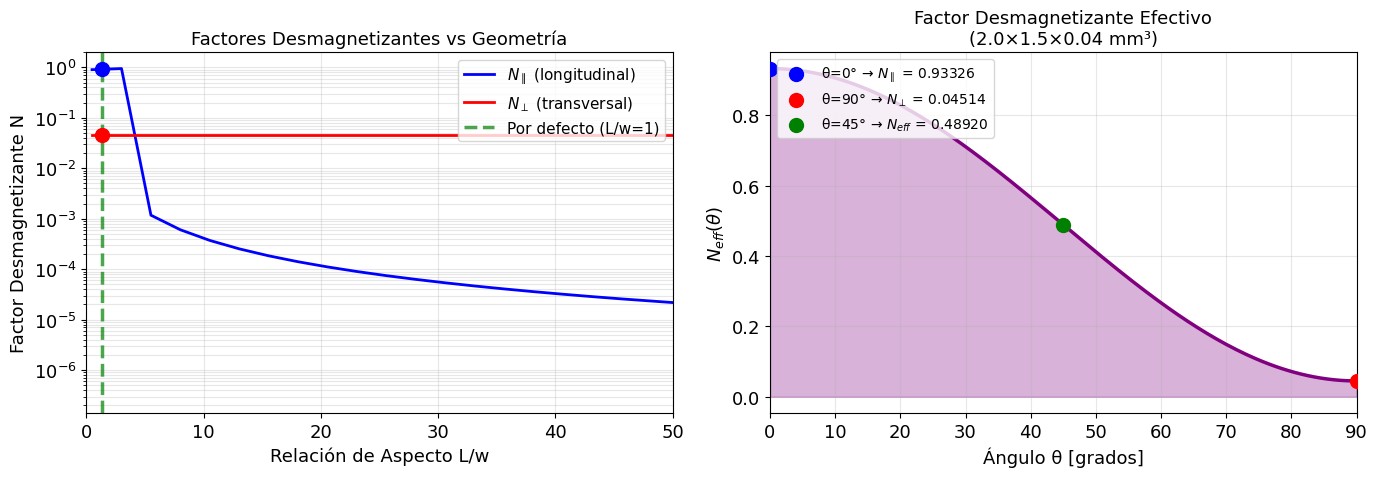


✓ Figura guardada como 'demagnetizing_factors_analysis.png'


In [7]:
# =============================================================================
# ANÁLISIS DE FACTORES DESMAGNETIZANTES vs GEOMETRÍA
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =============================================================================
# Subplot 1: N vs Relación de aspecto L/w
# =============================================================================
ax1 = axes[0]

L_w_ratios = np.linspace(0.5, 500, 200)
w_test = 1.5
t_test = 0.04

N_par_array = []
N_perp_array = []

for ratio in L_w_ratios:
    L_test = ratio * w_test
    N_par, N_perp = calculate_demagnetizing_factors(L_test, w_test, t_test)
    N_par_array.append(N_par)
    N_perp_array.append(N_perp)

ax1.semilogy(L_w_ratios, N_par_array, 'b-', linewidth=2, label='$N_\\parallel$ (longitudinal)')
ax1.semilogy(L_w_ratios, N_perp_array, 'r-', linewidth=2, label='$N_\\perp$ (transversal)')

# Marcar el valor por defecto
default_ratio = L_default / w_default
N_par_def, N_perp_def = calculate_demagnetizing_factors(L_default, w_default, t_default)
ax1.axvline(x=default_ratio, color='green', linestyle='--', alpha=0.7, label=f'Por defecto (L/w={default_ratio:.0f})')
ax1.scatter([default_ratio], [N_par_def], color='blue', s=100, zorder=5)
ax1.scatter([default_ratio], [N_perp_def], color='red', s=100, zorder=5)

ax1.set_xlabel('Relación de Aspecto L/w', fontsize=13)
ax1.set_ylabel('Factor Desmagnetizante N', fontsize=13)
ax1.set_title('Factores Desmagnetizantes vs Geometría', fontsize=13)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim([0, 50])

# =============================================================================
# Subplot 2: N_eff vs Ángulo θ
# =============================================================================
ax2 = axes[1]

theta_array = np.linspace(0, 90, 181)
theta_rad = np.radians(theta_array)

N_par_fixed, N_perp_fixed = calculate_demagnetizing_factors(L_default, w_default, t_default)
N_eff_array = N_par_fixed * np.cos(theta_rad)**2 + N_perp_fixed * np.sin(theta_rad)**2

ax2.plot(theta_array, N_eff_array, 'purple', linewidth=2.5)
ax2.fill_between(theta_array, N_eff_array, alpha=0.3, color='purple')

# Marcar puntos importantes
ax2.scatter([0], [N_par_fixed], color='blue', s=100, zorder=5, label=f'θ=0° → $N_\\parallel$ = {N_par_fixed:.5f}')
ax2.scatter([90], [N_perp_fixed], color='red', s=100, zorder=5, label=f'θ=90° → $N_\\perp$ = {N_perp_fixed:.5f}')
ax2.scatter([45], [N_eff_array[90]], color='green', s=100, zorder=5, 
            label=f'θ=45° → $N_{{eff}}$ = {N_eff_array[90]:.5f}')

ax2.set_xlabel('Ángulo θ [grados]', fontsize=13)
ax2.set_ylabel('$N_{eff}(\\theta)$', fontsize=13)
ax2.set_title(f'Factor Desmagnetizante Efectivo\n({L_default}×{w_default}×{t_default} mm³)', fontsize=13)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 90])

plt.tight_layout()
plt.savefig('demagnetizing_factors_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figura guardada como 'demagnetizing_factors_analysis.png'")

## 8. Cálculo de la Permeabilidad Efectiva

La **permeabilidad efectiva** ($\mu_{eff}$) está directamente afectada por el factor desmagnetizante:

$$\mu_{eff} = \frac{\mu_r}{1 + N \cdot (\mu_r - 1)}$$

Para materiales con muy alta permeabilidad ($\mu_r >> 1$), esto se simplifica a:

$$\mu_{eff} \approx \frac{1}{N}$$

Esto explica por qué el factor desmagnetizante domina completamente el comportamiento de materiales ferromagnéticos blandos.

In [8]:
# =============================================================================
# CÁLCULO DE PERMEABILIDAD EFECTIVA
# =============================================================================

def calculate_effective_permeability(mu_r, N):
    """
    Calcula la permeabilidad efectiva considerando el factor desmagnetizante.
    
    μ_eff = μ_r / (1 + N·(μ_r - 1))
    """
    return mu_r / (1 + N * (mu_r - 1))


# Permeabilidad intrínseca típica del material (muy alta para aleaciones amorfas)
mu_r_intrinsic = 100000  # Permeabilidad relativa intrínseca

print("═" * 70)
print("ANÁLISIS DE PERMEABILIDAD EFECTIVA")
print("═" * 70)
print(f"\nPermeabilidad intrínseca del material: μᵣ = {mu_r_intrinsic:,}")
print(f"\nGeometría: {L_default} × {w_default} × {t_default} mm³")
print("-" * 70)

# Calcular para diferentes orientaciones
orientations = [0, 45, 90]
N_par, N_perp = calculate_demagnetizing_factors(L_default, w_default, t_default)

print(f"{'Ángulo θ':^15} {'N_eff':^15} {'μ_eff':^20} {'μ_eff ≈ 1/N':^15}")
print("-" * 70)

for theta in orientations:
    theta_rad = np.radians(theta)
    N_eff = N_par * np.cos(theta_rad)**2 + N_perp * np.sin(theta_rad)**2
    mu_eff = calculate_effective_permeability(mu_r_intrinsic, N_eff)
    mu_approx = 1/N_eff if N_eff > 0 else float('inf')
    print(f"{theta:^15}° {N_eff:^15.6f} {mu_eff:^20,.0f} {mu_approx:^15,.0f}")

print("-" * 70)
print("\n✓ La aproximación μ_eff ≈ 1/N es válida cuando μᵣ >> 1")
print("  (el factor desmagnetizante domina completamente la respuesta)")

══════════════════════════════════════════════════════════════════════
ANÁLISIS DE PERMEABILIDAD EFECTIVA
══════════════════════════════════════════════════════════════════════

Permeabilidad intrínseca del material: μᵣ = 100,000

Geometría: 2.0 × 1.5 × 0.04 mm³
----------------------------------------------------------------------
   Ángulo θ          N_eff             μ_eff           μ_eff ≈ 1/N  
----------------------------------------------------------------------
       0       °    0.933256              1                  1       
      45       °    0.489196              2                  2       
      90       °    0.045136              22                22       
----------------------------------------------------------------------

✓ La aproximación μ_eff ≈ 1/N es válida cuando μᵣ >> 1
  (el factor desmagnetizante domina completamente la respuesta)


## 9. Resumen y Conclusiones

### Observaciones Clave:

1. **Efecto de Geometría (L/w)**:
   - Mayor relación de aspecto → Menor $N_\parallel$ → Ciclo más vertical
   - Esto maximiza la permeabilidad efectiva en la dirección longitudinal

2. **Efecto de Orientación (θ)**:
   - A θ = 0°: El campo desmagnetizante es mínimo ($N_\parallel$)
   - A θ = 90°: El campo desmagnetizante es máximo ($N_\perp$)
   - El cizallamiento del ciclo aumenta dramáticamente con θ

3. **Permeabilidad Efectiva**:
   - Para materiales de alta permeabilidad: $\mu_{eff} \approx 1/N$
   - La geometría determina las propiedades magnéticas observables

4. **Aplicaciones Prácticas**:
   - Sensores magnéticos: Optimizar geometría para maximizar sensibilidad
   - Núcleos de transformadores: Minimizar factor desmagnetizante
   - Cintas amorfas: Corte y orientación críticos para el rendimiento

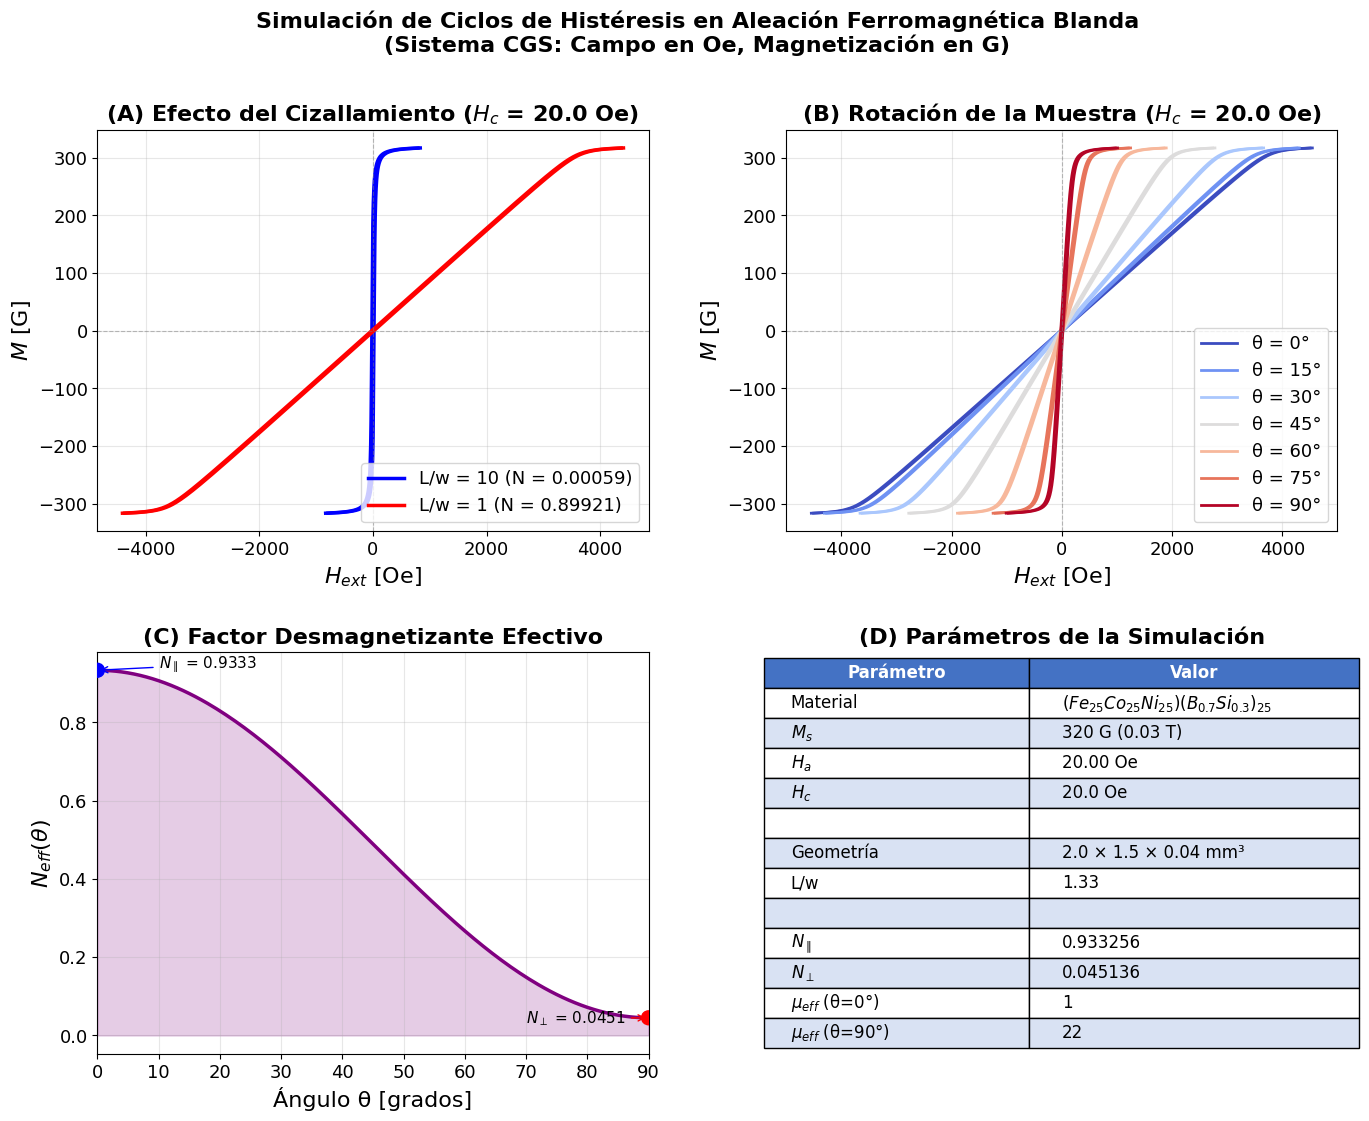


✓ Figura de resumen con ciclos abiertos (Hc = 20.0 Oe)


In [9]:
# =============================================================================
# FIGURA FINAL DE RESUMEN (UNIDADES CGS) - CON CICLOS ABIERTOS
# =============================================================================

fig = plt.figure(figsize=(16, 12))

# Crear grid de subplots
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
n_points = 500  # puntos por rama

# =============================================================================
# Panel A: Ciclo ideal vs con cizallamiento
# =============================================================================
ax1 = fig.add_subplot(gs[0, 0])

# Ciclo "ideal" (N muy pequeño, L/w muy grande)
M_ideal, H_ideal, N_ideal, _, _ = calculate_hysteresis(10, 1, 0.04, 0, Ms_default, Ha_default, Hc_default, n_points)
# Ciclo con cizallamiento moderado (L/w más pequeño)
M_shear, H_shear, N_shear, _, _ = calculate_hysteresis(1, 1, 0.04, 0, Ms_default, Ha_default, Hc_default, n_points)

# Separar ramas para ciclo ideal
M_ideal_up, M_ideal_down = M_ideal[:n_points], M_ideal[n_points:]
H_ideal_up, H_ideal_down = H_ideal[:n_points], H_ideal[n_points:]

# Separar ramas para ciclo con cizallamiento
M_shear_up, M_shear_down = M_shear[:n_points], M_shear[n_points:]
H_shear_up, H_shear_down = H_shear[:n_points], H_shear[n_points:]

# Graficar ambas ramas con mismo color
ax1.plot(H_ideal_up, M_ideal_up, 'b-', linewidth=2.5, label=f'L/w = 10 (N = {N_ideal:.5f})')
ax1.plot(H_ideal_down, M_ideal_down, 'b-', linewidth=2.5)
ax1.plot(H_shear_up, M_shear_up, 'r-', linewidth=2.5, label=f'L/w = 1 (N = {N_shear:.5f})')
ax1.plot(H_shear_down, M_shear_down, 'r-', linewidth=2.5)

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('$H_{ext}$ [Oe]')
ax1.set_ylabel('$M$ [G]')
ax1.set_title(f'(A) Efecto del Cizallamiento ($H_c$ = {Hc_default} Oe)', fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-max(abs(H_shear))*1.1, max(abs(H_shear))*1.1])

# =============================================================================
# Panel B: Rotación de muestra
# =============================================================================
ax2 = fig.add_subplot(gs[0, 1])

angles_plot = [0, 15, 30, 45, 60, 75, 90]
colors_plot = plt.cm.coolwarm(np.linspace(0, 1, len(angles_plot)))

for i, angle in enumerate(angles_plot):
    M, H, N_eff, _, _ = calculate_hysteresis(L_default, w_default, t_default, angle, Ms_default, Ha_default, Hc_default, n_points)
    # Separar ramas
    M_up, M_down = M[:n_points], M[n_points:]
    H_up, H_down = H[:n_points], H[n_points:]
    # Graficar ambas ramas con mismo color
    ax2.plot(H_up, M_up, color=colors_plot[i], linewidth=2, label=f'θ = {angle}°')
    ax2.plot(H_down, M_down, color=colors_plot[i], linewidth=2)

ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('$H_{ext}$ [Oe]')
ax2.set_ylabel('$M$ [G]')
ax2.set_title(f'(B) Rotación de la Muestra ($H_c$ = {Hc_default} Oe)', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# =============================================================================
# Panel C: N_eff vs θ
# =============================================================================
ax3 = fig.add_subplot(gs[1, 0])

theta_fine = np.linspace(0, 90, 181)
theta_rad_fine = np.radians(theta_fine)
N_par_f, N_perp_f = calculate_demagnetizing_factors(L_default, w_default, t_default)
N_eff_fine = N_par_f * np.cos(theta_rad_fine)**2 + N_perp_f * np.sin(theta_rad_fine)**2

ax3.plot(theta_fine, N_eff_fine, 'purple', linewidth=2.5)
ax3.fill_between(theta_fine, 0, N_eff_fine, alpha=0.2, color='purple')
ax3.scatter([0, 90], [N_par_f, N_perp_f], color=['blue', 'red'], s=100, zorder=5)
ax3.annotate(f'$N_\\parallel$ = {N_par_f:.4f}', xy=(0, N_par_f), xytext=(10, N_par_f + 0.005),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='blue'))
ax3.annotate(f'$N_\\perp$ = {N_perp_f:.4f}', xy=(90, N_perp_f), xytext=(70, N_perp_f*0.7),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'))
ax3.set_xlabel('Ángulo θ [grados]')
ax3.set_ylabel('$N_{eff}(θ)$')
ax3.set_title('(C) Factor Desmagnetizante Efectivo', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, 90])

# =============================================================================
# Panel D: Tabla resumen (UNIDADES CGS)
# =============================================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

cell_text = [
    ['Material', '$(Fe_{25}Co_{25}Ni_{25})(B_{0.7}Si_{0.3})_{25}$'],
    ['$M_s$', f'{Ms_default:.0f} G ({Ms_default/1e4:.2f} T)'],
    ['$H_a$', f'{Ha_default:.2f} Oe'],
    ['$H_c$', f'{Hc_default:.1f} Oe'],
    ['', ''],
    ['Geometría', f'{L_default} × {w_default} × {t_default} mm³'],
    ['L/w', f'{L_default/w_default:.2f}'],
    ['', ''],
    ['$N_\\parallel$', f'{N_par_f:.6f}'],
    ['$N_\\perp$', f'{N_perp_f:.6f}'],
    ['$\\mu_{eff}$ (θ=0°)', f'{1/N_par_f:,.0f}'],
    ['$\\mu_{eff}$ (θ=90°)', f'{1/N_perp_f:,.0f}'],
]

table = ax4.table(cellText=cell_text, colLabels=['Parámetro', 'Valor'],
                  loc='center', cellLoc='left', colWidths=[0.4, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white')
    elif i % 2 == 0:
        cell.set_facecolor('#D9E2F3')

ax4.set_title('(D) Parámetros de la Simulación', fontweight='bold', y=1)

plt.suptitle('Simulación de Ciclos de Histéresis en Aleación Ferromagnética Blanda\n(Sistema CGS: Campo en Oe, Magnetización en G)', 
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('hysteresis_summary_CGS.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Figura de resumen con ciclos abiertos (Hc = {Hc_default} Oe)")

# Medidas Finales - Análisis de Histéresis Magnética

Este notebook analiza y grafica los datos de medidas VSM (Vibrating Sample Magnetometer) de muestras FeCoNiBSi (aleaciones metálicas amorfas).

## 1. Fundamentos Teóricos

### 1.1 Histéresis Magnética

La **histéresis magnética** es un fenómeno característico de los materiales ferromagnéticos, donde la magnetización $M$ de un material no depende únicamente del campo magnético aplicado $H$, sino también de su historia magnética previa.

Cuando un material ferromagnético es sometido a un campo magnético externo cíclico, se observa una curva cerrada llamada **ciclo de histéresis**. Esta curva se caracteriza por:

- **Magnetización de saturación** ($M_s$): Valor máximo de magnetización alcanzable cuando todos los momentos magnéticos están alineados.
- **Magnetización remanente** ($M_r$): Magnetización residual cuando el campo aplicado es cero.
- **Campo coercitivo** ($H_c$): Campo magnético necesario para reducir la magnetización a cero.

### 1.2 Materiales Amorfos FeCoNiBSi

Las aleaciones amorfas de FeCoNiBSi son materiales **magnéticamente blandos** que presentan:
- Baja coercitividad ($H_c$ pequeño)
- Alta permeabilidad magnética
- Bajas pérdidas por histéresis

Estas propiedades los hacen ideales para aplicaciones en transformadores, sensores magnéticos y dispositivos de almacenamiento.

### 1.3 Magnetómetro de Muestra Vibrante (VSM)

El VSM mide el momento magnético $m$ de una muestra haciéndola vibrar en presencia de un campo magnético uniforme. La muestra oscilante induce una señal de voltaje en bobinas de detección, proporcional al momento magnético:

$$V_{señal} \propto m \cdot \omega \cdot A$$

donde $\omega$ es la frecuencia de vibración y $A$ es la amplitud.

## 2. Metodología del Análisis

### 2.1 Estructura de los Datos

Los archivos `.DAT` del VSM contienen múltiples columnas de información. Para este análisis, las variables principales son:

| Variable | Símbolo | Unidad | Descripción |
|----------|---------|--------|-------------|
| Campo Magnético | $H$ | Oe (Oersted) | Campo externo aplicado |
| Momento Magnético | $m$ | emu | Momento magnético de la muestra |
| Error Estándar | $\sigma_m$ | emu | Incertidumbre en la medida del momento |

### 2.2 Corrección por Ruido de Fondo

El sistema de medición presenta una señal de ruido de fondo que debe ser sustraída de las medidas. Si $m_{medido}(H)$ es el momento medido y $m_{ruido}(H)$ es la señal de ruido:

$$m_{corregido}(H) = m_{medido}(H) - m_{ruido}(H)$$

El archivo `ruido.dat` contiene la medida de esta señal de fondo realizada en las mismas condiciones experimentales.

In [10]:
# Ruta a la carpeta con los datos
carpeta = 'Medidas_final'

# Buscar todos los archivos .DAT (excluyendo ruido.dat)
todos_archivos = glob.glob(os.path.join(carpeta, '*.DAT')) + glob.glob(os.path.join(carpeta, '*.dat'))
archivos_dat = [f for f in todos_archivos if 'ruido' not in os.path.basename(f).lower()]

# Verificar si existe el archivo de ruido
archivo_ruido = None
for f in todos_archivos:
    if 'ruido' in os.path.basename(f).lower():
        archivo_ruido = f
        break

print(f"Archivos de medidas encontrados: {len(archivos_dat)}")
for archivo in archivos_dat:
    print(f"  - {os.path.basename(archivo)}")

if archivo_ruido:
    print(f"\n✓ Archivo de ruido encontrado: {os.path.basename(archivo_ruido)}")
else:
    print(f"\n⚠ Archivo de ruido (ruido.dat) no encontrado - las medidas no serán corregidas")

Archivos de medidas encontrados: 5
  - FECONIBSI-M4-0-MVSH-300K.DAT
  - FECONIBSI-M1-45-MVSH-300K.DAT
  - FECONIBSI-M8-15-MVSH-300K.DAT
  - FECONIBSI-M4-15-MVSH-300K.DAT
  - FECONIBSI-M8-30-MVSH-300K.DAT

✓ Archivo de ruido encontrado: ruido.DAT


### 2.3 Propagación de Errores

Al restar la señal de ruido, el error se propaga mediante **suma en cuadratura**. Si $\sigma_{medida}$ es el error de la medida y $\sigma_{ruido}$ es el error del ruido:

$$\sigma_{corregido} = \sqrt{\sigma_{medida}^2 + \sigma_{ruido}^2}$$

Esta fórmula asume que los errores son independientes y siguen una distribución normal. La interpolación del ruido a los valores de campo de cada medida se realiza mediante interpolación lineal.

### 2.4 Proceso de Análisis

El análisis sigue estos pasos:
1. **Carga de datos**: Lectura de archivos `.DAT` excluyendo el archivo de ruido
2. **Carga del ruido**: Lectura del archivo `ruido.dat` si está disponible
3. **Interpolación**: Ajuste de los puntos de ruido a los valores de campo de cada medida
4. **Corrección**: Sustracción del ruido y propagación de errores
5. **Visualización**: Generación de gráficas con barras de error

## 3. Carga de Datos Experimentales y Características de Muestras

En esta sección cargamos:
1. El archivo JSON con las **características geométricas** de cada muestra (L, w, t)
2. Los archivos `.DAT` del VSM con las medidas de histéresis

### Interpretación del nombre de archivo

Los archivos tienen el formato: `FECONIBSI-MX-YY-MVSH-300K.DAT` donde:
- `MX`: Identificador de muestra (M1, M4, M8, etc.)
- `YY`: Código de ángulo con el campo magnético:
  - `0` → 90°
  - `15` → 75°
  - `30` → 60°
  - `45` → 45°
  
La relación es: **θ_real = 90° - θ_código**

In [11]:
import json
import re

# =============================================================================
# CARGAR CARACTERÍSTICAS DE MUESTRAS DESDE JSON
# =============================================================================

json_path = os.path.join(carpeta, 'caracteristicas_muestras.json')

with open(json_path, 'r', encoding='utf-8') as f:
    caracteristicas_json = json.load(f)

# Extraer información de muestras en un diccionario más accesible
muestras_info = {}
datos_muestras = caracteristicas_json["Muestras todas de FeCoNiBSi"]

for key, value in datos_muestras.items():
    if key.startswith("Muestra"):
        identificador = value["Identificador"]  # M1, M4, M8, etc.
        muestras_info[identificador] = {
            'Largo': value["Largo"],
            'Ancho': value["Ancho"],
            'Espesor': value["Espesor"],
            'Incertidumbre_L_w': float(datos_muestras["Incertidumbre de Largo y Ancho"]),
            'Incertidumbre_t': float(datos_muestras["Incertidumbre de Espesor"])
        }

print("CARACTERÍSTICAS DE MUESTRAS (desde JSON)")
print("=" * 60)
for muestra_id, info in muestras_info.items():
    volumen = info['Largo'] * info['Ancho'] * info['Espesor']
    print(f"\n{muestra_id}:")
    print(f"  Dimensiones: {info['Largo']} × {info['Ancho']} × {info['Espesor']} mm³")
    print(f"  Volumen: {volumen:.4f} mm³ = {volumen/1000:.6f} cm³")
    print(f"  L/w: {info['Largo']/info['Ancho']:.2f}")

CARACTERÍSTICAS DE MUESTRAS (desde JSON)

M1:
  Dimensiones: 2.9 × 1.85 × 0.04 mm³
  Volumen: 0.2146 mm³ = 0.000215 cm³
  L/w: 1.57

M4:
  Dimensiones: 1.8 × 1.4 × 0.04 mm³
  Volumen: 0.1008 mm³ = 0.000101 cm³
  L/w: 1.29

M8:
  Dimensiones: 1.35 × 1.3 × 0.04 mm³
  Volumen: 0.0702 mm³ = 0.000070 cm³
  L/w: 1.04

M9:
  Dimensiones: 1.25 × 1.2 × 0.04 mm³
  Volumen: 0.0600 mm³ = 0.000060 cm³
  L/w: 1.04


In [12]:
# =============================================================================
# PARSEAR NOMBRES DE ARCHIVO Y ASOCIAR INFORMACIÓN
# =============================================================================

def parsear_nombre_archivo(nombre_archivo):
    """
    Extrae información del nombre de archivo.
    
    Formato: FECONIBSI-MX-YY.DAT donde:
    - X: número de muestra (1, 4, 8, etc.)
    - YY: código de ángulo (0→90°, 15→75°, 30→60°, 45→45°)
    
    Returns: diccionario con 'muestra', 'codigo_angulo', 'angulo_real'
    """
    # Patrón: busca M seguido de número, luego guion, luego número de ángulo
    patron = r'FECONIBSI-M(\d+)-(\d+)'
    match = re.search(patron, nombre_archivo, re.IGNORECASE)
    
    if match:
        num_muestra = match.group(1)
        codigo_angulo = int(match.group(2))
        #angulo_real = 90 - codigo_angulo  # Conversión: 0→90°, 15→75°, 45→45°, etc.
        angulo_real = codigo_angulo  # Conversión: 0→90°, 15→75°, 45→45°, etc.
        
        return {
            'muestra': f'M{num_muestra}',
            'codigo_angulo': codigo_angulo,
            'angulo_real': angulo_real
        }
    return None

# Procesar todos los archivos de medición (excepto ruido)
info_archivos = {}
print("ARCHIVOS DE MEDICIÓN ENCONTRADOS")
print("=" * 70)
print(f"{'Archivo':<30} {'Muestra':<10} {'θ_código':<10} {'θ_real':<10}")
print("-" * 70)

for archivo in archivos_dat:
    nombre = os.path.basename(archivo)
    if 'ruido' not in nombre.lower():
        info = parsear_nombre_archivo(nombre)
        if info:
            info_archivos[archivo] = info
            print(f"{nombre:<30} {info['muestra']:<10} {info['codigo_angulo']}°{'':<7} {info['angulo_real']}°")

print("-" * 70)
print(f"Total: {len(info_archivos)} archivos de medición procesados")

ARCHIVOS DE MEDICIÓN ENCONTRADOS
Archivo                        Muestra    θ_código   θ_real    
----------------------------------------------------------------------
FECONIBSI-M4-0-MVSH-300K.DAT   M4         0°        0°
FECONIBSI-M1-45-MVSH-300K.DAT  M1         45°        45°
FECONIBSI-M8-15-MVSH-300K.DAT  M8         15°        15°
FECONIBSI-M4-15-MVSH-300K.DAT  M4         15°        15°
FECONIBSI-M8-30-MVSH-300K.DAT  M8         30°        30°
----------------------------------------------------------------------
Total: 5 archivos de medición procesados


In [13]:
# =============================================================================
# FUNCIONES PARA LEER Y PROCESAR DATOS VSM
# =============================================================================

def leer_archivo_vsm(ruta_archivo):
    """
    Lee un archivo .DAT del VSM y extrae los datos relevantes.
    
    Returns: DataFrame con columnas ['H_Oe', 'M_emu', 'Error_emu']
    """
    try:
        # El archivo tiene encabezado, leer y determinar estructura
        # Probar diferentes codificaciones
        for encoding in ['latin-1', 'utf-8', 'iso-8859-1', 'cp1252']:
            try:
                with open(ruta_archivo, 'r', encoding=encoding) as f:
                    lineas = f.readlines()
                break
            except UnicodeDecodeError:
                continue
        
        # Buscar línea de encabezado de datos
        inicio_datos = 0
        for i, linea in enumerate(lineas):
            if 'Magnetic Field' in linea or 'Field' in linea:
                inicio_datos = i
                break
        
        # Leer datos con pandas, saltando el encabezado descriptivo
        df = pd.read_csv(ruta_archivo, skiprows=inicio_datos, 
                        delimiter=',', engine='python', encoding=encoding)
        
        # Renombrar columnas relevantes
        df_limpio = pd.DataFrame()
        
        # Campo magnético en Oe
        for col in df.columns:
            if 'Magnetic Field' in col and 'Oe' in col:
                df_limpio['H_Oe'] = pd.to_numeric(df[col], errors='coerce')
                break
        
        # Momento magnético en emu
        for col in df.columns:
            if 'Moment' in col and 'emu' in col and 'Std' not in col:
                df_limpio['M_emu'] = pd.to_numeric(df[col], errors='coerce')
                break
        
        # Error del momento
        for col in df.columns:
            if 'M. Std. Err' in col:
                df_limpio['Error_emu'] = pd.to_numeric(df[col], errors='coerce')
                break
        
        # Eliminar filas con NaN
        df_limpio = df_limpio.dropna()
        
        return df_limpio
    
    except Exception as e:
        print(f"Error leyendo {ruta_archivo}: {e}")
        return None

def restar_ruido(df_datos, df_ruido):
    """
    Resta la contribución del ruido (portamuestras) de los datos.
    Interpola el ruido a los mismos valores de campo de los datos.
    
    Returns: DataFrame con momento corregido
    """
    from scipy.interpolate import interp1d
    
    # Crear interpolador del ruido
    interp_ruido = interp1d(df_ruido['H_Oe'], df_ruido['M_emu'], 
                           kind='linear', fill_value='extrapolate')
    
    # Interpolar ruido a los valores de H de los datos
    ruido_interpolado = interp_ruido(df_datos['H_Oe'])
    
    # Crear nuevo DataFrame con datos corregidos
    df_corregido = df_datos.copy()
    df_corregido['M_emu_sin_ruido'] = df_datos['M_emu'] - ruido_interpolado
    df_corregido['M_ruido'] = ruido_interpolado
    
    return df_corregido

# Leer archivo de ruido
print("LECTURA DE DATOS VSM")
print("=" * 60)

df_ruido = leer_archivo_vsm(archivo_ruido)
if df_ruido is not None:
    print(f"✓ Ruido cargado: {len(df_ruido)} puntos")
    print(f"  Rango H: [{df_ruido['H_Oe'].min():.1f}, {df_ruido['H_Oe'].max():.1f}] Oe")
    print(f"  Rango M: [{df_ruido['M_emu'].min():.2e}, {df_ruido['M_emu'].max():.2e}] emu")

LECTURA DE DATOS VSM
✓ Ruido cargado: 28 puntos
  Rango H: [-1000.0, 1000.0] Oe
  Rango M: [-2.83e-05, 2.90e-05] emu


In [14]:
# =============================================================================
# CARGAR TODOS LOS DATOS DE MEDICIÓN Y CALCULAR MAGNETIZACIÓN
# =============================================================================

datos_mediciones = {}

print("PROCESAMIENTO DE MEDICIONES")
print("=" * 80)

for archivo, info in info_archivos.items():
    muestra = info['muestra']
    angulo = info['angulo_real']
    
    # Obtener características de la muestra
    if muestra in muestras_info:
        caract = muestras_info[muestra]
        L_mm = caract['Largo']
        w_mm = caract['Ancho']
        t_mm = caract['Espesor']
        
        # Calcular volumen en cm³
        volumen_cm3 = (L_mm * w_mm * t_mm) / 1000  # mm³ a cm³
        
        # Leer datos
        df = leer_archivo_vsm(archivo)
        
        if df is not None:
            # Restar ruido
            df = restar_ruido(df, df_ruido)
            
            # Calcular magnetización: M [G] = m [emu] / V [cm³]
            df['M_G'] = df['M_emu_sin_ruido'] / volumen_cm3
            df['M_G_raw'] = df['M_emu'] / volumen_cm3  # Sin corrección de ruido
            
            # Guardar datos
            clave = f"{muestra}_θ{angulo}"
            datos_mediciones[clave] = {
                'df': df,
                'muestra': muestra,
                'angulo': angulo,
                'L': L_mm,
                'w': w_mm,
                't': t_mm,
                'volumen': volumen_cm3,
                'archivo': os.path.basename(archivo)
            }
            
            print(f"\n{muestra} a θ = {angulo}°:")
            print(f"  Archivo: {os.path.basename(archivo)}")
            print(f"  Dimensiones: {L_mm} × {w_mm} × {t_mm} mm³")
            print(f"  Volumen: {volumen_cm3:.6f} cm³")
            print(f"  Puntos: {len(df)}")
            print(f"  Rango H: [{df['H_Oe'].min():.1f}, {df['H_Oe'].max():.1f}] Oe")
            print(f"  Rango M: [{df['M_G'].min():.1f}, {df['M_G'].max():.1f}] G")
    else:
        print(f"⚠ Muestra {muestra} no encontrada en características JSON")

print("\n" + "=" * 80)
print(f"Total: {len(datos_mediciones)} mediciones procesadas")

PROCESAMIENTO DE MEDICIONES

M4 a θ = 0°:
  Archivo: FECONIBSI-M4-0-MVSH-300K.DAT
  Dimensiones: 1.8 × 1.4 × 0.04 mm³
  Volumen: 0.000101 cm³
  Puntos: 33
  Rango H: [-999.9, 1000.0] Oe
  Rango M: [-71.7, 70.5] G

M1 a θ = 45°:
  Archivo: FECONIBSI-M1-45-MVSH-300K.DAT
  Dimensiones: 2.9 × 1.85 × 0.04 mm³
  Volumen: 0.000215 cm³
  Puntos: 40
  Rango H: [-999.9, 1000.0] Oe
  Rango M: [-360.7, 360.2] G

M8 a θ = 15°:
  Archivo: FECONIBSI-M8-15-MVSH-300K.DAT
  Dimensiones: 1.35 × 1.3 × 0.04 mm³
  Volumen: 0.000070 cm³
  Puntos: 35
  Rango H: [-1000.0, 1000.1] Oe
  Rango M: [-301.0, 300.0] G

M4 a θ = 15°:
  Archivo: FECONIBSI-M4-15-MVSH-300K.DAT
  Dimensiones: 1.8 × 1.4 × 0.04 mm³
  Volumen: 0.000101 cm³
  Puntos: 34
  Rango H: [-1000.0, 1000.0] Oe
  Rango M: [-208.1, 207.7] G

M8 a θ = 30°:
  Archivo: FECONIBSI-M8-30-MVSH-300K.DAT
  Dimensiones: 1.35 × 1.3 × 0.04 mm³
  Volumen: 0.000070 cm³
  Puntos: 33
  Rango H: [-999.9, 1000.0] Oe
  Rango M: [-357.7, 356.4] G

Total: 5 mediciones proce

### 3.1 Gráficas de Ciclos de Histéresis Experimentales

Se grafican los ciclos de histéresis medidos organizados por muestra. Cada gráfica muestra las mediciones a diferentes ángulos θ (ángulo entre el campo aplicado y el eje largo de la muestra).

**Muestras disponibles:**
- **M1**: $2.9 \times 1.85 \times 0.04$ mm³ (L/w = 1.57)
- **M4**: $1.8 \times 1.4 \times 0.04$ mm³ (L/w = 1.29)  
- **M8**: $1.35 \times 1.3 \times 0.04$ mm³ (L/w = 1.04)

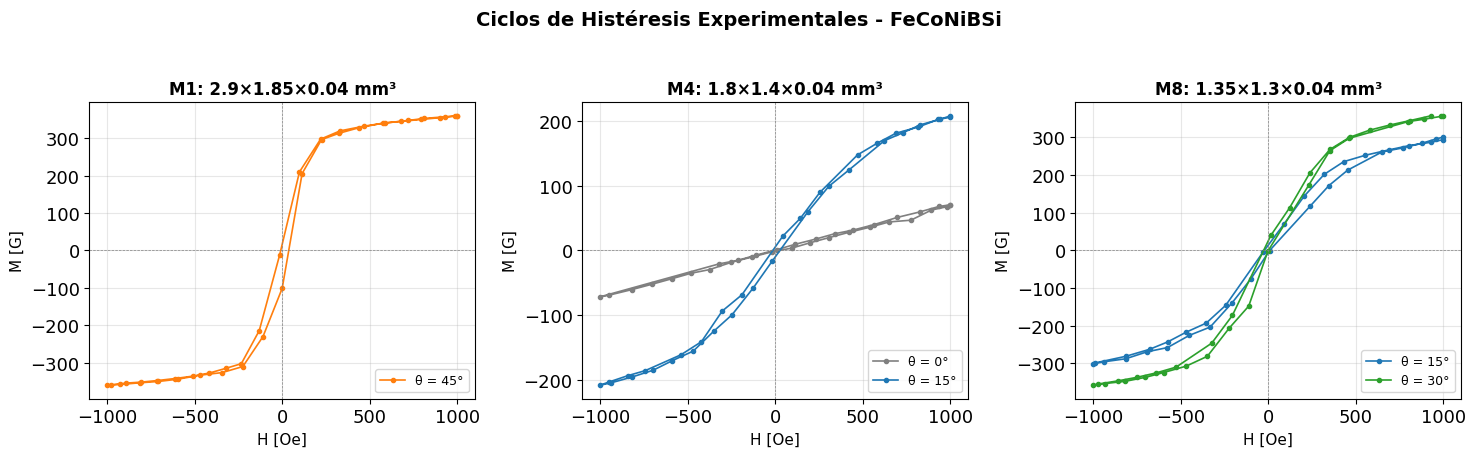


Leyenda de ángulos:
θ = ángulo entre el campo aplicado H y el eje largo L de la muestra
θ = 90° → campo perpendicular al eje largo (paralelo al ancho)
θ = 45° → campo a 45° del eje largo
θ = 0° → campo paralelo al eje largo


In [15]:
# =============================================================================
# GRÁFICAS DE CICLOS DE HISTÉRESIS EXPERIMENTALES POR MUESTRA
# =============================================================================

# Organizar datos por muestra
muestras_unicas = set(info['muestra'] for info in datos_mediciones.values())
muestras_unicas = sorted(muestras_unicas)

# Colores para diferentes ángulos
colores_angulo = {
    15: 'tab:blue',
    30: 'tab:green', 
    45: 'tab:orange',
    60: 'tab:red',
    70: 'tab:purple'
}

fig, axes = plt.subplots(1, len(muestras_unicas), figsize=(5*len(muestras_unicas), 4.5))
if len(muestras_unicas) == 1:
    axes = [axes]

for ax, muestra in zip(axes, muestras_unicas):
    # Filtrar datos de esta muestra
    datos_muestra = {k: v for k, v in datos_mediciones.items() if v['muestra'] == muestra}
    
    # Ordenar por ángulo
    datos_ordenados = sorted(datos_muestra.items(), key=lambda x: x[1]['angulo'])
    
    for clave, info in datos_ordenados:
        df = info['df']
        angulo = info['angulo']
        color = colores_angulo.get(angulo, 'gray')
        
        ax.plot(df['H_Oe'], df['M_G'], 'o-', 
                color=color, markersize=3, linewidth=1.2,
                label=f'θ = {angulo}°')
    
    # Obtener características de la muestra
    caract = muestras_info.get(muestra, {})
    L = caract.get('Largo', '?')
    w = caract.get('Ancho', '?')
    t = caract.get('Espesor', '?')
    
    ax.set_xlabel('H [Oe]', fontsize=11)
    ax.set_ylabel('M [G]', fontsize=11)
    ax.set_title(f'{muestra}: {L}×{w}×{t} mm³', fontsize=12, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Ciclos de Histéresis Experimentales - FeCoNiBSi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nLeyenda de ángulos:")
print("θ = ángulo entre el campo aplicado H y el eje largo L de la muestra")
print("θ = 90° → campo perpendicular al eje largo (paralelo al ancho)")
print("θ = 45° → campo a 45° del eje largo")
print("θ = 0° → campo paralelo al eje largo")

### 3.2 Ajuste de Parámetros del Modelo

Se ajustan automáticamente los parámetros del modelo ($M_s$, $H_a$, $H_c$) minimizando el error cuadrático medio entre los datos experimentales y la simulación teórica. Se usa el método de optimización de Nelder-Mead (simplex) de `scipy.optimize`.

In [16]:
# =============================================================================
# AJUSTE AUTOMÁTICO DE PARÁMETROS DEL MODELO
# =============================================================================

from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import interp1d

def funcion_objetivo_v2(params, datos_exp_list, L_mm, w_mm, t_mm, angulos):
    """
    Función objetivo: RMSE entre modelo y datos experimentales.
    Considera que los datos experimentales trazan un ciclo completo.
    """
    Ms, Ha, Hc = params
    
    # Límites físicos
    if Ms <= 10 or Ms > 1000:
        return 1e10
    if Ha < 0 or Ha > 50:
        return 1e10
    if Hc < 0 or Hc > 300:
        return 1e10
    
    error_total = 0
    n_puntos_total = 0
    
    for df_exp, angulo in zip(datos_exp_list, angulos):
        H_exp = df_exp['H_Oe'].values
        M_exp = df_exp['M_G'].values
        
        # Generar modelo teórico
        try:
            M_sim, H_sim, _, _, _ = calculate_hysteresis(
                L_mm, w_mm, t_mm, angulo, Ms, Ha, Hc, 200)
        except:
            return 1e10
        
        # Separar ramas del modelo
        n_half = len(M_sim) // 2
        H_up = H_sim[:n_half]
        M_up = M_sim[:n_half]
        H_down = H_sim[n_half:]
        M_down = M_sim[n_half:]
        
        # Crear interpoladores
        try:
            interp_up = interp1d(H_up, M_up, kind='linear', 
                                bounds_error=False, fill_value=(M_up[0], M_up[-1]))
            interp_down = interp1d(H_down, M_down, kind='linear',
                                  bounds_error=False, fill_value=(M_down[0], M_down[-1]))
        except:
            return 1e10
        
        # Calcular error: distancia mínima a cualquier rama
        for H_i, M_i in zip(H_exp, M_exp):
            M_up_i = interp_up(H_i)
            M_down_i = interp_down(H_i)
            error_min = min(abs(M_i - M_up_i), abs(M_i - M_down_i))
            error_total += error_min**2
            n_puntos_total += 1
    
    return np.sqrt(error_total / n_puntos_total) if n_puntos_total > 0 else 1e10

def ajustar_parametros_v2(muestra_id):
    """
    Ajusta los parámetros Ms, Ha, Hc usando evolución diferencial (búsqueda global).
    """
    # Obtener características de la muestra
    caract = muestras_info[muestra_id]
    L_mm, w_mm, t_mm = caract['Largo'], caract['Ancho'], caract['Espesor']
    
    # Filtrar datos experimentales
    datos_muestra = {k: v for k, v in datos_mediciones.items() if v['muestra'] == muestra_id}
    
    if not datos_muestra:
        print(f"No hay datos experimentales para {muestra_id}")
        return None
    
    # Preparar datos
    datos_exp_list = []
    angulos = []
    for clave, info in datos_muestra.items():
        datos_exp_list.append(info['df'])
        angulos.append(info['angulo'])
    
    # Estimar Ms desde datos
    Ms_obs = max(abs(df['M_G']).max() for df in datos_exp_list)
    
    # Límites para los parámetros: [Ms, Ha, Hc]
    # Ms: entre 50% y 200% del valor observado
    # Ha: campo de anisotropía típico 0.5 - 20 Oe para materiales blandos
    # Hc: coercitividad 5 - 150 Oe 
    bounds = [
        (Ms_obs * 0.5, min(Ms_obs * 2.0, 800)),  # Ms
        (0.1, 30),                                 # Ha
        (5, 100)                                   # Hc
    ]
    
    # Evolución diferencial - búsqueda global
    resultado = differential_evolution(
        funcion_objetivo_v2,
        bounds,
        args=(datos_exp_list, L_mm, w_mm, t_mm, angulos),
        maxiter=300,
        tol=0.01,
        seed=42,
        polish=True,  # Refinar con L-BFGS-B
        workers=1
    )
    
    Ms_opt, Ha_opt, Hc_opt = resultado.x
    rmse = resultado.fun
    
    return {
        'muestra': muestra_id,
        'Ms': Ms_opt,
        'Ha': Ha_opt,
        'Hc': Hc_opt,
        'RMSE': rmse,
        'exito': resultado.success,
        'L': L_mm,
        'w': w_mm,
        't': t_mm,
        'angulos': angulos,
        'Ms_obs': Ms_obs
    }

# =============================================================================
# EJECUTAR AJUSTE PARA TODAS LAS MUESTRAS
# =============================================================================

print("AJUSTE AUTOMÁTICO DE PARÁMETROS DEL MODELO")
print("=" * 70)
print("Método: Evolución Diferencial (búsqueda global) + refinamiento local")
print("Límites: Ms ∈ [0.5·Ms_obs, 2·Ms_obs], Ha ∈ [0.1, 30] Oe, Hc ∈ [5, 100] Oe")

resultados_ajuste = {}

for muestra_id in sorted(set(v['muestra'] for v in datos_mediciones.values())):
    print(f"\n{'─'*70}")
    print(f"Ajustando {muestra_id}...")
    
    resultado = ajustar_parametros_v2(muestra_id)
    
    if resultado:
        resultados_ajuste[muestra_id] = resultado
        print(f"\n  ✓ Parámetros óptimos para {muestra_id}:")
        print(f"    Ms = {resultado['Ms']:.1f} G  (observado: {resultado['Ms_obs']:.1f} G)")
        print(f"    Ha = {resultado['Ha']:.2f} Oe")
        print(f"    Hc = {resultado['Hc']:.1f} Oe")
        print(f"    RMSE = {resultado['RMSE']:.2f} G")
        print(f"    Ángulos: {resultado['angulos']}")

print(f"\n{'='*70}")
print("RESUMEN DE PARÁMETROS AJUSTADOS")
print("=" * 70)
print(f"{'Muestra':<8} {'L/w':<6} {'Ms [G]':<10} {'Ha [Oe]':<10} {'Hc [Oe]':<10} {'RMSE [G]':<10}")
print("-" * 70)
for muestra_id, res in resultados_ajuste.items():
    Lw_ratio = res['L'] / res['w']
    print(f"{muestra_id:<8} {Lw_ratio:<6.2f} {res['Ms']:<10.1f} {res['Ha']:<10.2f} {res['Hc']:<10.1f} {res['RMSE']:<10.2f}")

AJUSTE AUTOMÁTICO DE PARÁMETROS DEL MODELO
Método: Evolución Diferencial (búsqueda global) + refinamiento local
Límites: Ms ∈ [0.5·Ms_obs, 2·Ms_obs], Ha ∈ [0.1, 30] Oe, Hc ∈ [5, 100] Oe

──────────────────────────────────────────────────────────────────────
Ajustando M1...

  ✓ Parámetros óptimos para M1:
    Ms = 706.6 G  (observado: 360.7 G)
    Ha = 0.10 Oe
    Hc = 100.0 Oe
    RMSE = 213.17 G
    Ángulos: [45]

──────────────────────────────────────────────────────────────────────
Ajustando M4...

  ✓ Parámetros óptimos para M4:
    Ms = 355.9 G  (observado: 208.1 G)
    Ha = 0.10 Oe
    Hc = 100.0 Oe
    RMSE = 64.70 G
    Ángulos: [0, 15]

──────────────────────────────────────────────────────────────────────
Ajustando M8...

  ✓ Parámetros óptimos para M8:
    Ms = 712.4 G  (observado: 357.7 G)
    Ha = 0.10 Oe
    Hc = 100.0 Oe
    RMSE = 190.83 G
    Ángulos: [15, 30]

RESUMEN DE PARÁMETROS AJUSTADOS
Muestra  L/w    Ms [G]     Ha [Oe]    Hc [Oe]    RMSE [G]  
----------------

### 3.3 Visualización de los Ajustes

Se grafican los ciclos de histéresis experimentales junto con las curvas del modelo usando los parámetros ajustados automáticamente.

GRÁFICAS DE AJUSTES

→ M1


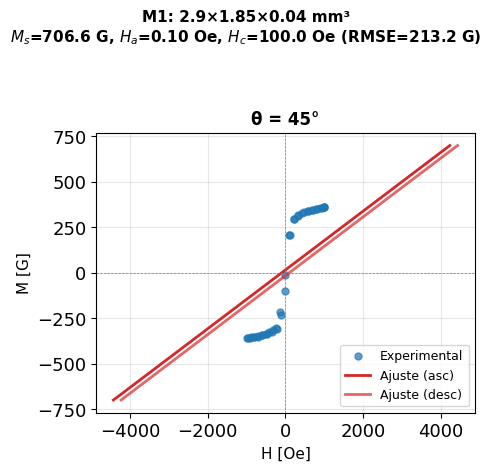


→ M4


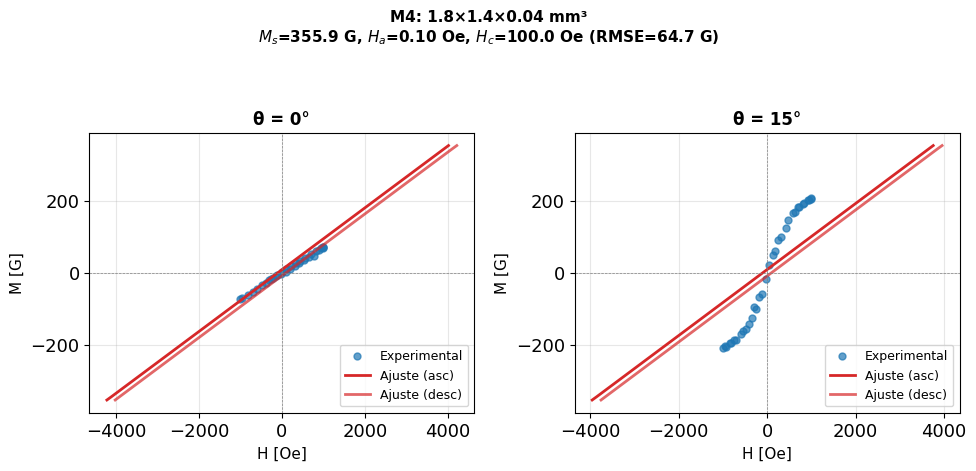


→ M8


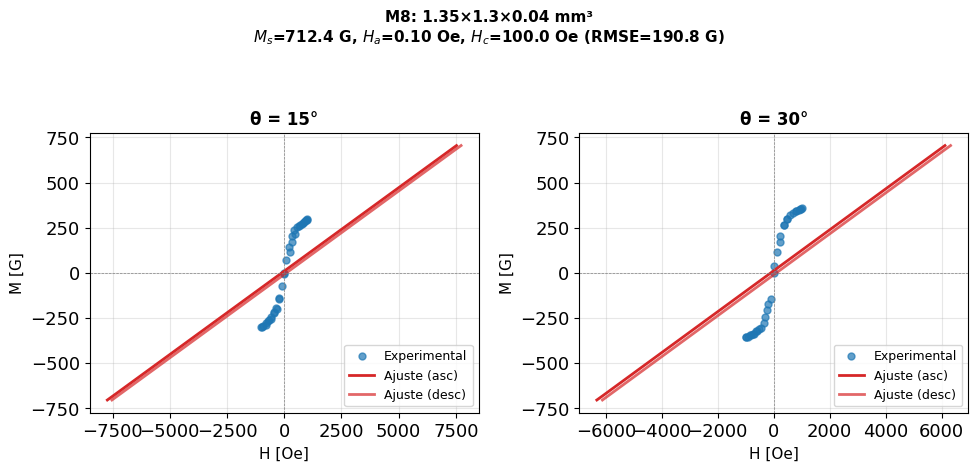

In [17]:
# =============================================================================
# VISUALIZACIÓN DE AJUSTES
# =============================================================================

def graficar_ajuste(resultado, n_points=500):
    """
    Grafica la comparación entre datos experimentales y el modelo ajustado.
    """
    muestra_id = resultado['muestra']
    Ms_fit = resultado['Ms']
    Ha_fit = resultado['Ha']
    Hc_fit = resultado['Hc']
    L_mm = resultado['L']
    w_mm = resultado['w']
    t_mm = resultado['t']
    angulos = resultado['angulos']
    
    # Filtrar datos experimentales
    datos_muestra = {k: v for k, v in datos_mediciones.items() if v['muestra'] == muestra_id}
    n_angulos = len(angulos)
    
    fig, axes = plt.subplots(1, n_angulos, figsize=(5*n_angulos, 4.5))
    if n_angulos == 1:
        axes = [axes]
    
    for ax, angulo in zip(axes, sorted(angulos)):
        # Datos experimentales
        clave = f"{muestra_id}_θ{angulo}"
        if clave in datos_mediciones:
            df_exp = datos_mediciones[clave]['df']
            ax.plot(df_exp['H_Oe'], df_exp['M_G'], 'o', 
                   color='tab:blue', markersize=5, label='Experimental', alpha=0.7)
        
        # Modelo ajustado
        M_sim, H_sim, N_eff, _, _ = calculate_hysteresis(
            L_mm, w_mm, t_mm, angulo, Ms_fit, Ha_fit, Hc_fit, n_points)
        
        # Separar ramas
        n_half = len(M_sim) // 2
        ax.plot(H_sim[:n_half], M_sim[:n_half], '-', color='tab:red', 
               linewidth=2, label='Ajuste (asc)')
        ax.plot(H_sim[n_half:], M_sim[n_half:], '-', color='tab:red', 
               linewidth=2, alpha=0.7, label='Ajuste (desc)')
        
        ax.set_xlabel('H [Oe]', fontsize=11)
        ax.set_ylabel('M [G]', fontsize=11)
        ax.set_title(f'θ = {angulo}°', fontsize=12, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    titulo = f'{muestra_id}: {L_mm}×{w_mm}×{t_mm} mm³\n'
    titulo += f'$M_s$={Ms_fit:.1f} G, $H_a$={Ha_fit:.2f} Oe, $H_c$={Hc_fit:.1f} Oe (RMSE={resultado["RMSE"]:.1f} G)'
    plt.suptitle(titulo, fontsize=11, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Graficar resultados para cada muestra
print("GRÁFICAS DE AJUSTES")
print("=" * 60)

for muestra_id, resultado in resultados_ajuste.items():
    print(f"\n→ {muestra_id}")
    graficar_ajuste(resultado)

### 3.4 Ajuste Alternativo: Método Basin-Hopping + Mínimos Cuadrados

Probamos un método alternativo que combina:
1. **Basin-hopping**: Algoritmo de optimización global estocástico
2. **Función objetivo mejorada**: Considera separadamente las ramas ascendente y descendente
3. **Restricciones físicas**: Límites basados en propiedades típicas de materiales magnéticos blandos

In [18]:
# =============================================================================
# AJUSTE ALTERNATIVO: BASIN-HOPPING + MÍNIMOS CUADRADOS
# =============================================================================

from scipy.optimize import basinhopping, least_squares
from scipy.interpolate import interp1d

def separar_ramas_experimentales(H_exp, M_exp):
    """
    Separa los datos experimentales en rama ascendente y descendente
    basándose en el cambio de signo de dH/dt.
    """
    # Calcular diferencias en H
    dH = np.diff(H_exp)
    
    # Encontrar puntos de cambio de dirección
    cambios = np.where(np.diff(np.sign(dH)) != 0)[0]
    
    if len(cambios) == 0:
        # Si no hay cambios, asumir que todo es una rama
        return H_exp, M_exp, np.array([]), np.array([])
    
    # Punto de cambio principal (cerca del máximo o mínimo de H)
    idx_cambio = cambios[len(cambios)//2] + 1
    
    # Determinar cuál es ascendente y cuál descendente
    if np.mean(dH[:idx_cambio]) > 0:
        H_asc, M_asc = H_exp[:idx_cambio], M_exp[:idx_cambio]
        H_desc, M_desc = H_exp[idx_cambio:], M_exp[idx_cambio:]
    else:
        H_desc, M_desc = H_exp[:idx_cambio], M_exp[:idx_cambio]
        H_asc, M_asc = H_exp[idx_cambio:], M_exp[idx_cambio:]
    
    return H_asc, M_asc, H_desc, M_desc

def funcion_residuos(params, datos_exp_list, L_mm, w_mm, t_mm, angulos):
    """
    Calcula residuos para least_squares.
    Compara cada punto experimental con la rama correspondiente del modelo.
    """
    Ms, Ha, Hc = params
    
    # Límites físicos
    if Ms <= 10 or Ms > 1000 or Ha < 0 or Ha > 100 or Hc < 0 or Hc > 500:
        return np.full(100, 1e6)
    
    residuos = []
    
    for df_exp, angulo in zip(datos_exp_list, angulos):
        H_exp = df_exp['H_Oe'].values
        M_exp = df_exp['M_G'].values
        
        # Generar modelo teórico
        try:
            M_sim, H_sim, _, _, _ = calculate_hysteresis(
                L_mm, w_mm, t_mm, angulo, Ms, Ha, Hc, 300)
        except:
            return np.full(len(H_exp), 1e6)
        
        # Separar ramas del modelo
        n_half = len(M_sim) // 2
        H_up_mod = H_sim[:n_half]
        M_up_mod = M_sim[:n_half]
        H_down_mod = H_sim[n_half:]
        M_down_mod = M_sim[n_half:]
        
        # Interpoladores
        try:
            interp_up = interp1d(H_up_mod, M_up_mod, kind='linear',
                                bounds_error=False, fill_value='extrapolate')
            interp_down = interp1d(H_down_mod, M_down_mod, kind='linear',
                                  bounds_error=False, fill_value='extrapolate')
        except:
            return np.full(len(H_exp), 1e6)
        
        # Para cada punto experimental, calcular residuo mínimo
        for H_i, M_i in zip(H_exp, M_exp):
            M_up_i = interp_up(H_i)
            M_down_i = interp_down(H_i)
            # Usar el residuo de la rama más cercana
            res_up = M_i - M_up_i
            res_down = M_i - M_down_i
            if abs(res_up) < abs(res_down):
                residuos.append(res_up)
            else:
                residuos.append(res_down)
    
    return np.array(residuos)

def ajustar_basin_hopping(muestra_id, n_iter=50):
    """
    Ajusta parámetros usando Basin-Hopping para búsqueda global
    combinado con least_squares para refinamiento local.
    """
    caract = muestras_info[muestra_id]
    L_mm, w_mm, t_mm = caract['Largo'], caract['Ancho'], caract['Espesor']
    
    datos_muestra = {k: v for k, v in datos_mediciones.items() if v['muestra'] == muestra_id}
    
    if not datos_muestra:
        return None
    
    datos_exp_list = []
    angulos = []
    for clave, info in datos_muestra.items():
        datos_exp_list.append(info['df'])
        angulos.append(info['angulo'])
    
    Ms_obs = max(abs(df['M_G']).max() for df in datos_exp_list)
    
    # Función objetivo para basin-hopping
    def objetivo_bh(params):
        residuos = funcion_residuos(params, datos_exp_list, L_mm, w_mm, t_mm, angulos)
        return np.sum(residuos**2)
    
    # Límites para los parámetros
    bounds_min = [Ms_obs * 0.3, 0.1, 5]
    bounds_max = [Ms_obs * 1.8, 50, 250]
    
    class MyBounds:
        def __init__(self, xmin, xmax):
            self.xmin = np.array(xmin)
            self.xmax = np.array(xmax)
        def __call__(self, **kwargs):
            x = kwargs["x_new"]
            return np.all(x >= self.xmin) and np.all(x <= self.xmax)
    
    mybounds = MyBounds(bounds_min, bounds_max)
    
    # Punto inicial
    x0 = [Ms_obs, 5.0, 50.0]
    
    # Basin-hopping
    minimizer_kwargs = {"method": "L-BFGS-B", 
                        "bounds": list(zip(bounds_min, bounds_max))}
    
    resultado_bh = basinhopping(
        objetivo_bh, x0,
        minimizer_kwargs=minimizer_kwargs,
        niter=n_iter,
        accept_test=mybounds,
        seed=42
    )
    
    # Refinamiento con least_squares
    resultado_ls = least_squares(
        funcion_residuos,
        resultado_bh.x,
        args=(datos_exp_list, L_mm, w_mm, t_mm, angulos),
        bounds=(bounds_min, bounds_max),
        method='trf'
    )
    
    Ms_opt, Ha_opt, Hc_opt = resultado_ls.x
    
    # Calcular RMSE
    residuos_final = funcion_residuos(resultado_ls.x, datos_exp_list, L_mm, w_mm, t_mm, angulos)
    rmse = np.sqrt(np.mean(residuos_final**2))
    
    return {
        'muestra': muestra_id,
        'Ms': Ms_opt,
        'Ha': Ha_opt,
        'Hc': Hc_opt,
        'RMSE': rmse,
        'exito': resultado_ls.success,
        'L': L_mm,
        'w': w_mm,
        't': t_mm,
        'angulos': angulos,
        'Ms_obs': Ms_obs
    }

# =============================================================================
# EJECUTAR AJUSTE CON BASIN-HOPPING
# =============================================================================

print("AJUSTE ALTERNATIVO: BASIN-HOPPING + LEAST SQUARES")
print("=" * 70)
print("Método: Basin-hopping (50 iteraciones) + refinamiento TRF")

resultados_ajuste_v2 = {}

for muestra_id in sorted(set(v['muestra'] for v in datos_mediciones.values())):
    print(f"\n{'─'*70}")
    print(f"Ajustando {muestra_id}...")
    
    resultado = ajustar_basin_hopping(muestra_id, n_iter=50)
    
    if resultado:
        resultados_ajuste_v2[muestra_id] = resultado
        print(f"\n  ✓ Parámetros óptimos para {muestra_id}:")
        print(f"    Ms = {resultado['Ms']:.1f} G  (observado: {resultado['Ms_obs']:.1f} G)")
        print(f"    Ha = {resultado['Ha']:.2f} Oe")
        print(f"    Hc = {resultado['Hc']:.1f} Oe")
        print(f"    RMSE = {resultado['RMSE']:.2f} G")

# Comparación de métodos
print(f"\n{'='*70}")
print("COMPARACIÓN DE MÉTODOS DE AJUSTE")
print("=" * 70)
print(f"{'Muestra':<8} {'Método':<20} {'Ms [G]':<10} {'Ha [Oe]':<10} {'Hc [Oe]':<10} {'RMSE [G]':<10}")
print("-" * 70)

for muestra_id in sorted(resultados_ajuste.keys()):
    r1 = resultados_ajuste[muestra_id]
    r2 = resultados_ajuste_v2.get(muestra_id)
    
    print(f"{muestra_id:<8} {'Evol. Diferencial':<20} {r1['Ms']:<10.1f} {r1['Ha']:<10.2f} {r1['Hc']:<10.1f} {r1['RMSE']:<10.2f}")
    if r2:
        mejor = "← MEJOR" if r2['RMSE'] < r1['RMSE'] else ""
        print(f"{'':<8} {'Basin-Hopping':<20} {r2['Ms']:<10.1f} {r2['Ha']:<10.2f} {r2['Hc']:<10.1f} {r2['RMSE']:<10.2f} {mejor}")

AJUSTE ALTERNATIVO: BASIN-HOPPING + LEAST SQUARES
Método: Basin-hopping (50 iteraciones) + refinamiento TRF

──────────────────────────────────────────────────────────────────────
Ajustando M1...

  ✓ Parámetros óptimos para M1:
    Ms = 649.3 G  (observado: 360.7 G)
    Ha = 0.10 Oe
    Hc = 250.0 Oe
    RMSE = 189.61 G

──────────────────────────────────────────────────────────────────────
Ajustando M4...

  ✓ Parámetros óptimos para M4:
    Ms = 374.5 G  (observado: 208.1 G)
    Ha = 0.10 Oe
    Hc = 250.0 Oe
    RMSE = 56.49 G

──────────────────────────────────────────────────────────────────────
Ajustando M8...

  ✓ Parámetros óptimos para M8:
    Ms = 643.9 G  (observado: 357.7 G)
    Ha = 0.10 Oe
    Hc = 250.0 Oe
    RMSE = 176.23 G

COMPARACIÓN DE MÉTODOS DE AJUSTE
Muestra  Método               Ms [G]     Ha [Oe]    Hc [Oe]    RMSE [G]  
----------------------------------------------------------------------
M1       Evol. Diferencial    706.6      0.10       100.0      213.17

GRÁFICAS DE AJUSTES - MÉTODO BASIN-HOPPING

→ M1


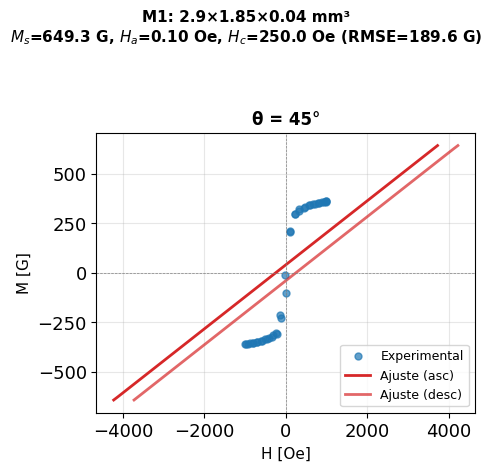


→ M4


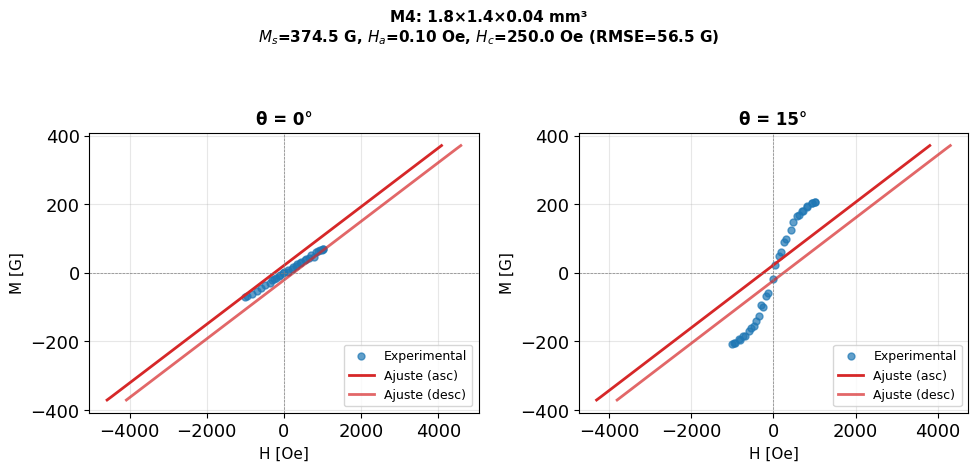


→ M8


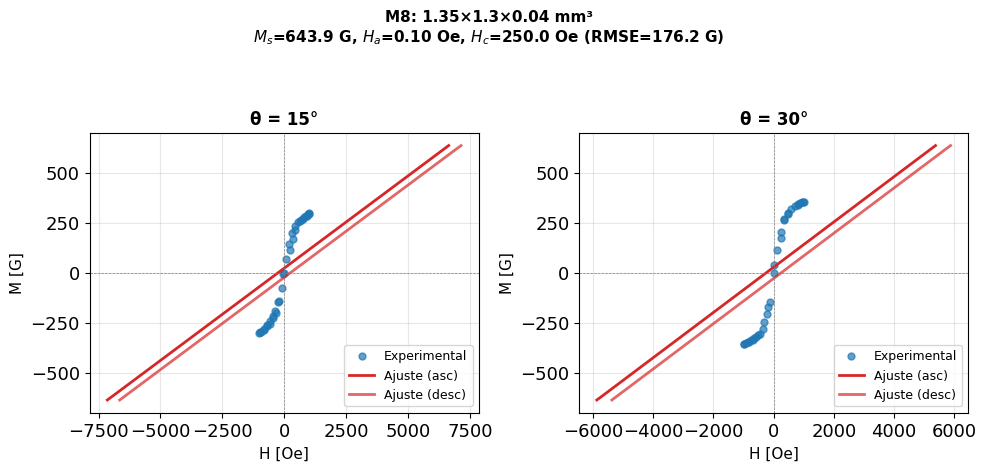

In [19]:
# =============================================================================
# VISUALIZACIÓN DE AJUSTES - MÉTODO BASIN-HOPPING
# =============================================================================

print("GRÁFICAS DE AJUSTES - MÉTODO BASIN-HOPPING")
print("=" * 60)

for muestra_id, resultado in resultados_ajuste_v2.items():
    print(f"\n→ {muestra_id}")
    graficar_ajuste(resultado)

### 3.5 Comparación con Parámetros Específicos

Evaluación del modelo teórico usando los parámetros físicos estimados:
- $M_s = 320$ G (magnetización de saturación)
- $H_c = 20$ Oe (campo coercitivo)
- $H_a = 19$ Oe (campo de anisotropía)

EVALUACIÓN DEL MODELO CON PARÁMETROS ESPECÍFICOS

Parámetros teóricos:
  Ms = 320.0 G
  Ha = 19.0 Oe
  Hc = 20.0 Oe


M4 a θ = 0°:
  N_eff = 0.9287
  |M_exp|_max = 71.7 G
  RMSE = 7.70 G
  MAE  = 6.12 G
  Error máximo = 17.63 G
  Error relativo ≈ 10.7%

M1 a θ = 45°:
  N_eff = 0.4921
  |M_exp|_max = 360.7 G
  RMSE = 226.79 G
  MAE  = 221.73 G
  Error máximo = 271.49 G
  Error relativo ≈ 62.9%

M8 a θ = 15°:
  N_eff = 0.8604
  |M_exp|_max = 301.0 G
  RMSE = 174.69 G
  MAE  = 165.01 G
  Error máximo = 210.95 G
  Error relativo ≈ 58.0%

M4 a θ = 15°:
  N_eff = 0.8697
  |M_exp|_max = 208.1 G
  RMSE = 97.90 G
  MAE  = 92.51 G
  Error máximo = 119.69 G
  Error relativo ≈ 47.0%

M8 a θ = 30°:
  N_eff = 0.7016
  |M_exp|_max = 357.7 G
  RMSE = 222.07 G
  MAE  = 212.63 G
  Error máximo = 255.60 G
  Error relativo ≈ 62.1%

RESUMEN DE DIFERENCIAS
Muestra  θ      RMSE [G]     MAE [G]      Max Err [G]  Err Rel % 
----------------------------------------------------------------------
M4       0      

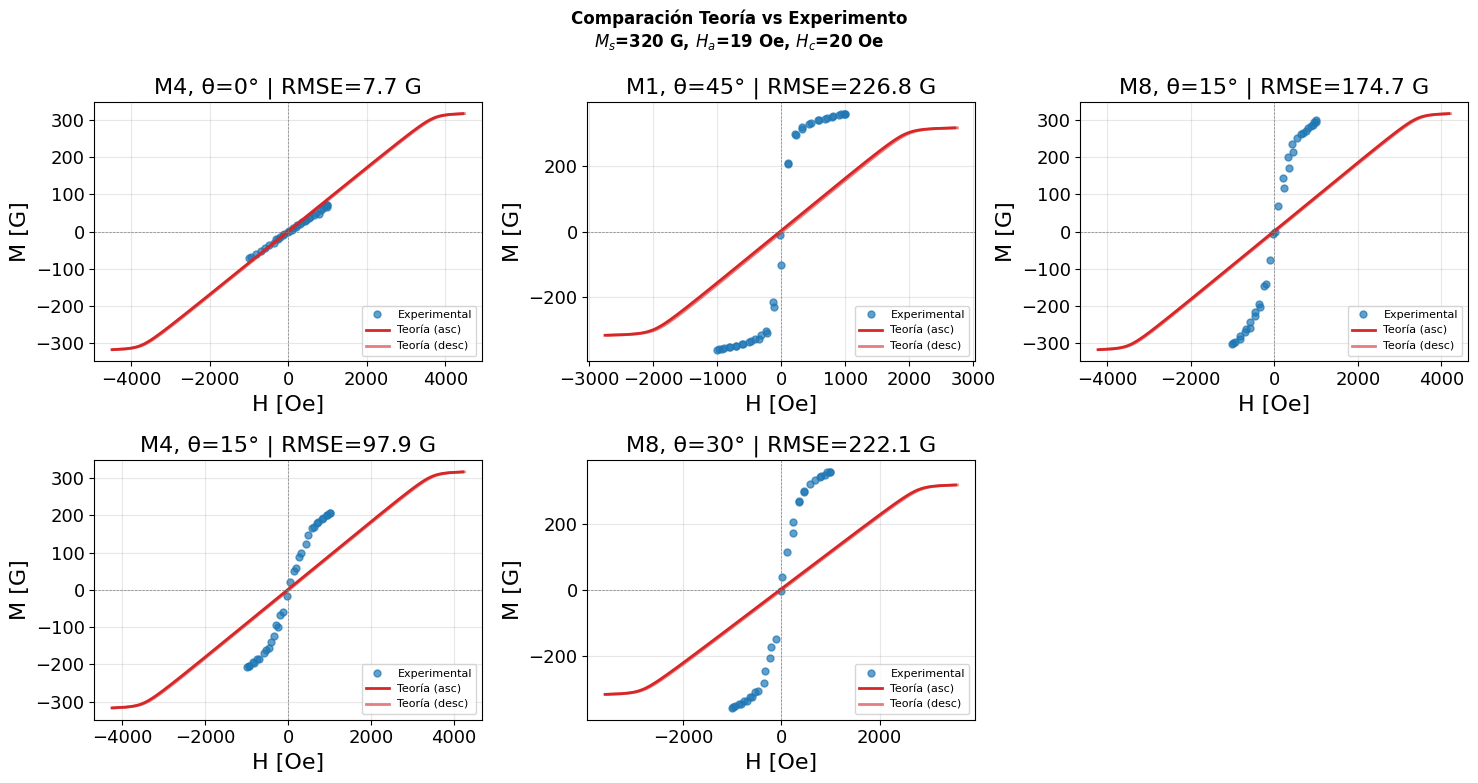


RMSE PROMEDIO GLOBAL: 145.83 G


In [20]:
# =============================================================================
# COMPARACIÓN CON PARÁMETROS ESPECÍFICOS
# =============================================================================

# Parámetros físicos especificados
Ms_teorico = 3.2e2    # 320 Gauss
Hc_teorico = 20.0     # Oersted - controla el ancho del ciclo
Ha_teorico = 19.0     # Oersted - campo de anisotropía

print("EVALUACIÓN DEL MODELO CON PARÁMETROS ESPECÍFICOS")
print("=" * 70)
print(f"\nParámetros teóricos:")
print(f"  Ms = {Ms_teorico:.1f} G")
print(f"  Ha = {Ha_teorico:.1f} Oe")
print(f"  Hc = {Hc_teorico:.1f} Oe")
print(f"\n{'='*70}")

# Calcular error para cada muestra/ángulo
resultados_comparacion = {}

for clave, info in datos_mediciones.items():
    muestra_id = info['muestra']
    angulo = info['angulo']
    df_exp = info['df']
    L_mm = info['L']
    w_mm = info['w']
    t_mm = info['t']
    
    H_exp = df_exp['H_Oe'].values
    M_exp = df_exp['M_G'].values
    
    # Calcular curva teórica
    M_sim, H_sim, N_eff, N_par, N_perp = calculate_hysteresis(
        L_mm, w_mm, t_mm, angulo, Ms_teorico, Ha_teorico, Hc_teorico, 300)
    
    # Separar ramas del modelo
    n_half = len(M_sim) // 2
    H_up_mod = H_sim[:n_half]
    M_up_mod = M_sim[:n_half]
    H_down_mod = H_sim[n_half:]
    M_down_mod = M_sim[n_half:]
    
    # Interpoladores para comparar
    interp_up = interp1d(H_up_mod, M_up_mod, kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    interp_down = interp1d(H_down_mod, M_down_mod, kind='linear',
                          bounds_error=False, fill_value='extrapolate')
    
    # Calcular diferencias punto a punto
    diferencias = []
    for H_i, M_i in zip(H_exp, M_exp):
        M_up_i = interp_up(H_i)
        M_down_i = interp_down(H_i)
        # Usar la diferencia mínima (a la rama más cercana)
        diff_min = min(abs(M_i - M_up_i), abs(M_i - M_down_i))
        diferencias.append(diff_min)
    
    diferencias = np.array(diferencias)
    rmse = np.sqrt(np.mean(diferencias**2))
    mae = np.mean(diferencias)
    max_error = np.max(diferencias)
    
    resultados_comparacion[clave] = {
        'muestra': muestra_id,
        'angulo': angulo,
        'RMSE': rmse,
        'MAE': mae,
        'Max_Error': max_error,
        'N_puntos': len(H_exp),
        'M_exp_max': np.max(np.abs(M_exp)),
        'H_sim': H_sim,
        'M_sim': M_sim
    }
    
    print(f"\n{muestra_id} a θ = {angulo}°:")
    print(f"  N_eff = {N_eff:.4f}")
    print(f"  |M_exp|_max = {np.max(np.abs(M_exp)):.1f} G")
    print(f"  RMSE = {rmse:.2f} G")
    print(f"  MAE  = {mae:.2f} G")
    print(f"  Error máximo = {max_error:.2f} G")
    print(f"  Error relativo ≈ {100*rmse/np.max(np.abs(M_exp)):.1f}%")

# =============================================================================
# RESUMEN Y GRÁFICAS
# =============================================================================

print(f"\n{'='*70}")
print("RESUMEN DE DIFERENCIAS")
print("=" * 70)
print(f"{'Muestra':<8} {'θ':<6} {'RMSE [G]':<12} {'MAE [G]':<12} {'Max Err [G]':<12} {'Err Rel %':<10}")
print("-" * 70)

for clave, res in resultados_comparacion.items():
    err_rel = 100 * res['RMSE'] / res['M_exp_max']
    print(f"{res['muestra']:<8} {res['angulo']:<6} {res['RMSE']:<12.2f} {res['MAE']:<12.2f} {res['Max_Error']:<12.2f} {err_rel:<10.1f}")

# Gráficas de comparación
n_mediciones = len(datos_mediciones)
n_cols = min(3, n_mediciones)
n_rows = (n_mediciones + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.atleast_2d(axes).flatten()

for idx, (clave, info) in enumerate(datos_mediciones.items()):
    ax = axes[idx]
    muestra_id = info['muestra']
    angulo = info['angulo']
    df_exp = info['df']
    
    res = resultados_comparacion[clave]
    H_sim = res['H_sim']
    M_sim = res['M_sim']
    n_half = len(M_sim) // 2
    
    # Datos experimentales
    ax.plot(df_exp['H_Oe'], df_exp['M_G'], 'o', color='tab:blue', 
           markersize=5, label='Experimental', alpha=0.7)
    
    # Modelo teórico
    ax.plot(H_sim[:n_half], M_sim[:n_half], '-', color='tab:red', 
           linewidth=2, label='Teoría (asc)')
    ax.plot(H_sim[n_half:], M_sim[n_half:], '-', color='tab:red', 
           linewidth=2, alpha=0.6, label='Teoría (desc)')
    
    ax.set_xlabel('H [Oe]')
    ax.set_ylabel('M [G]')
    ax.set_title(f'{muestra_id}, θ={angulo}° | RMSE={res["RMSE"]:.1f} G')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Ocultar ejes vacíos
for idx in range(len(datos_mediciones), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Comparación Teoría vs Experimento\n$M_s$={Ms_teorico:.0f} G, $H_a$={Ha_teorico:.0f} Oe, $H_c$={Hc_teorico:.0f} Oe', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Promedio global
rmse_promedio = np.mean([r['RMSE'] for r in resultados_comparacion.values()])
print(f"\n{'='*70}")
print(f"RMSE PROMEDIO GLOBAL: {rmse_promedio:.2f} G")
print("=" * 70)